# Sumativa 3 - Proyecto Final Integrado

## MCDI501 - Estadística Computacional para la Toma de Decisiones

### Magíster en Ciencia de Datos e Inteligencia Artificial

**Universidad Andrés Bello**

---

## Integrantes

- Pablo Rodríguez
- Luiskar Espinoza

---

## Objetivo

Desarrollar el proyecto final integrado del curso, aplicando modelos de regresión lineal y regresión logística para apoyar la toma de decisiones sobre el riesgo de enfermedad coronaria a diez años, integrando de manera trazable los resultados obtenidos durante las Sumativas 1 y 2 mediante análisis exploratorio, inferencia estadística, técnicas de remuestreo y simulación.

---

**Dataset utilizado**

Framingham Heart Study

# Índice

1. Importación de librerías

2. Configuración del proyecto

3. Carga del conjunto de datos

4. Integración de resultados de S1 y S2

## Parte 1 - Manejo inteligente de datos faltantes

5. Resultados provenientes de S1

6. Imputación simple

7. Imputación mediante regresión lineal múltiple

8. Comparación de estrategias de imputación

## Parte 2 - Modelamiento predictivo

9. Preparación del conjunto de datos

10. Modelo 1 (basado en S1 y S2)

11. Modelo 2 (selección Stepwise)

12. Modelo 3 (criterios AIC/BIC)

## Parte 3 - Bootstrap del modelo

13. Estabilidad de coeficientes

14. Intervalos de confianza Bootstrap

## Parte 4 - Diagnóstico del modelo

15. Multicolinealidad

16. Observaciones influyentes

17. Linealidad del logit

18. Residuos

## Parte 5 - Comparación de modelos

19. Comparación entre estrategias de imputación

20. Selección del modelo final

## Parte 6 - Exportación

21. Exportación de resultados

22. Síntesis final

# 1. Importación de librerías

In [2]:
# ==========================================
# Librerías principales
# ==========================================

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# Manejo de datos
# ==========================================

import numpy as np
import pandas as pd

# ==========================================
# Visualización
# ==========================================

import matplotlib.pyplot as plt

# ==========================================
# Machine Learning
# ==========================================

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.metrics import classification_report
# ==========================================
# Statsmodels
# ==========================================

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# 2. Configuración del proyecto

## Configuración de directorios

In [19]:
# ==========================================
# Directorios del proyecto
# ==========================================

PROJECT_ROOT = Path.cwd().parents[2]

DATA_PATH = (
    PROJECT_ROOT /
    "datos" /
    "original" /
    "framingham.csv"
)

FIGURES_DIR = (
    PROJECT_ROOT /
    "F4" /
    "Sumativa3" /
    "figures"
)

RESULTS_DIR = (
    PROJECT_ROOT /
    "F4" /
    "Sumativa3" /
    "results"
)

REPORT_DIR = (
    PROJECT_ROOT /
    "F4" /
    "Sumativa3" /
    "report"
)

PRESENTATION_DIR = (
    PROJECT_ROOT /
    "F4" /
    "Sumativa3" /
    "presentation"
)

# Crear directorios si no existen
FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PRESENTATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Directorios configurados correctamente.")

Directorios configurados correctamente.


## Configuración general

In [20]:
# ==========================================
# Parámetros generales
# ==========================================

SEED = 42

np.random.seed(SEED)

TEST_SIZE = 0.30

ALPHA = 0.05

N_BOOTSTRAP = 10000

print("Semilla:", SEED)

print("Nivel de significancia:", ALPHA)

print("Bootstrap:", N_BOOTSTRAP)

Semilla: 42
Nivel de significancia: 0.05
Bootstrap: 10000


# 3. Carga del conjunto de datos

## Carga y verificación del conjunto de datos

In [21]:
# ==========================================
# Carga del dataset
# ==========================================

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("Conjunto de datos cargado correctamente")
print("=" * 60)

print(f"Observaciones : {df.shape[0]}")

print(f"Variables     : {df.shape[1]}")

display(df.head())

Conjunto de datos cargado correctamente
Observaciones : 4238
Variables     : 16


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


# 4. Integración de resultados de S1 y S2

## Integración de resultados previos

La presente evaluación constituye la etapa final del proyecto, por lo que todas las decisiones metodológicas se fundamentan en los resultados obtenidos durante las evaluaciones anteriores.

**Resultados incorporados desde la Sumativa 1**

- Identificación de variables con valores faltantes.
- Caracterización del patrón de datos faltantes.
- Identificación de valores atípicos.
- Correlaciones entre variables clínicas.
- Pruebas de hipótesis sobre variables relevantes.
- Estadística descriptiva e inferencial.

**Resultados incorporados desde la Sumativa 2**

- Validación bootstrap de parámetros.
- Validación mediante test de permutación.
- Estabilidad de correlaciones.
- Simulación Monte Carlo.
- Análisis de robustez.
- Parámetros estadísticamente estables.

Estos antecedentes constituyen la base para la selección de variables, el tratamiento de datos faltantes y la construcción de los modelos predictivos desarrollados en esta evaluación.

# Parte 1 - Manejo inteligente de datos faltantes

## 5. Resultados provenientes de la Sumativa 1

Durante la Sumativa 1 se identificó la presencia de valores faltantes en diversas variables clínicas del conjunto de datos Framingham Heart Study.

En lugar de repetir dicho análisis, en esta etapa se utilizan esos resultados como insumo para definir y comparar distintas estrategias de tratamiento de datos faltantes, tal como establece la metodología del proyecto.

In [7]:
# ==========================================
# Resumen de valores faltantes (Resultados S1)
# ==========================================

faltantes = pd.DataFrame({

    "Valores faltantes": df.isnull().sum(),

    "Porcentaje (%)": (
        df.isnull().mean()*100
    ).round(2)

})

faltantes = faltantes[
    faltantes["Valores faltantes"] > 0
]

print("=" * 60)
print("Resumen de valores faltantes (S1)")
print("=" * 60)

display(faltantes)

Resumen de valores faltantes (S1)


,Valores faltantes,Porcentaje (%)
education,105,2.48
cigsPerDay,29,0.68
BPMeds,53,1.25
totChol,50,1.18
BMI,19,0.45
heartRate,1,0.02
glucose,388,9.16


## Variables con datos faltantes

La siguiente tabla resume las variables que presentan valores faltantes y constituye el punto de partida para comparar las tres estrategias de tratamiento consideradas en esta evaluación:

- Eliminación de observaciones (`dropna`).
- Imputación simple.
- Imputación mediante regresión lineal múltiple.

In [22]:
# ==========================================
# Variables que serán imputadas
# ==========================================

variables_faltantes = list(faltantes.index)

print("Variables con datos faltantes:\n")

for variable in variables_faltantes:
    print(f"• {variable}")

Variables con datos faltantes:

• education
• cigsPerDay
• BPMeds
• totChol
• BMI
• heartRate
• glucose


## Orden del tratamiento de datos faltantes

De acuerdo con la orientación metodológica entregada para esta evaluación, las tres estrategias de tratamiento de datos faltantes se aplican sobre la base completa antes de realizar la separación entre entrenamiento y prueba.

Posteriormente, cada conjunto resultante se divide utilizando la misma semilla y la misma asignación general de registros, con el propósito de mantener la reproducibilidad y facilitar la comparación entre estrategias.

In [23]:
# ==========================================
# Estrategias 1 y 2 sobre la base completa
# ==========================================

TARGET = "TenYearCHD"

# ------------------------------------------
# Estrategia 1: eliminación
# ------------------------------------------

df_dropna = df.dropna().copy()

# ------------------------------------------
# Estrategia 2: imputación simple
# ------------------------------------------

df_simple = df.copy()

columnas_moda = [
    columna
    for columna in ["education", "BPMeds"]
    if columna in df.columns
    and df[columna].isna().any()
]

columnas_mediana = [
    columna
    for columna in df.columns
    if columna != TARGET
    and columna not in columnas_moda
    and df[columna].isna().any()
]

imputador_moda = SimpleImputer(
    strategy="most_frequent"
)

imputador_mediana = SimpleImputer(
    strategy="median"
)

df_simple[columnas_moda] = (
    imputador_moda.fit_transform(
        df[columnas_moda]
    )
)

df_simple[columnas_mediana] = (
    imputador_mediana.fit_transform(
        df[columnas_mediana]
    )
)

print("=" * 60)
print("ESTRATEGIAS SOBRE LA BASE COMPLETA")
print("=" * 60)

print("Base original:", df.shape)
print("Eliminación:", df_dropna.shape)
print("Imputación simple:", df_simple.shape)

print("\nVariables imputadas con moda:")
print(columnas_moda)

print("\nVariables imputadas con mediana:")
print(columnas_mediana)

assert df_dropna.isna().sum().sum() == 0
assert df_simple.isna().sum().sum() == 0

print("\nValidación correcta: no existen valores faltantes.")

ESTRATEGIAS SOBRE LA BASE COMPLETA
Base original: (4238, 16)
Eliminación: (3656, 16)
Imputación simple: (4238, 16)

Variables imputadas con moda:
['education', 'BPMeds']

Variables imputadas con mediana:
['cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose']

Validación correcta: no existen valores faltantes.


## Estrategia 3: imputación por regresión de `glucose`

`glucose` es la variable con mayor cantidad de datos faltantes: 388 registros, equivalentes al 9,16 % de la base analizada.

Para esta estrategia, las demás variables incompletas se completan mediante métodos simples y `glucose` se imputa mediante regresión lineal múltiple. Se utilizan cinco predictores derivados del análisis previo: `diabetes`, `age`, `BMI`, `sysBP` y `totChol`.

El desempeño del modelo de imputación se evalúa mediante R², RMSE y MAE. Un R² bajo no se oculta, ya que refleja la débil relación lineal de `glucose` con los predictores disponibles.

In [24]:
# ==========================================
# Preparación de la imputación por regresión
# centrada en glucose
# ==========================================

df_regresion = df.copy()

# Variables ordinales o binarias
columnas_moda_regresion = [
    columna
    for columna in ["education", "BPMeds"]
    if columna in df_regresion.columns
    and df_regresion[columna].isna().any()
]

for columna in columnas_moda_regresion:

    valor_moda = (
        df_regresion[columna]
        .mode(dropna=True)
        .iloc[0]
    )

    df_regresion[columna] = (
        df_regresion[columna]
        .fillna(valor_moda)
    )

# Variables numéricas distintas de glucose
columnas_mediana_regresion = [
    columna
    for columna in variables_faltantes
    if columna not in (
        columnas_moda_regresion
        + ["glucose"]
    )
]

for columna in columnas_mediana_regresion:

    valor_mediana = (
        df_regresion[columna]
        .median()
    )

    df_regresion[columna] = (
        df_regresion[columna]
        .fillna(valor_mediana)
    )

predictores_glucose = [
    "diabetes",
    "age",
    "BMI",
    "sysBP",
    "totChol"
]

mascara_glucose_observada = (
    df_regresion["glucose"].notna()
)

datos_glucose_observados = (
    df_regresion.loc[
        mascara_glucose_observada,
        predictores_glucose + ["glucose"]
    ]
    .copy()
)

X_glucose = (
    datos_glucose_observados[
        predictores_glucose
    ]
)

y_glucose = (
    datos_glucose_observados["glucose"]
)

print("Registros observados de glucose:", len(y_glucose))
print(
    "Valores de glucose por imputar:",
    int(df_regresion["glucose"].isna().sum())
)

Registros observados de glucose: 3850
Valores de glucose por imputar: 388


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

print("SEED:", SEED)
print("X_glucose:", X_glucose.shape)
print("y_glucose:", y_glucose.shape)

print("\nFaltantes en X_glucose:")
print(X_glucose.isna().sum())

print("\nFaltantes en y_glucose:")
print(y_glucose.isna().sum())

SEED: 42
X_glucose: (3850, 5)
y_glucose: (3850,)

Faltantes en X_glucose:
diabetes    0
age         0
BMI         0
sysBP       0
totChol     0
dtype: int64

Faltantes en y_glucose:
0


In [26]:
# ==========================================
# Evaluación del modelo de imputación
# ==========================================

(
    X_glucose_ajuste,
    X_glucose_validacion,
    y_glucose_ajuste,
    y_glucose_validacion
) = train_test_split(
    X_glucose,
    y_glucose,
    test_size=0.20,
    random_state=SEED
)

modelo_glucose_evaluacion = LinearRegression()

modelo_glucose_evaluacion.fit(
    X_glucose_ajuste,
    y_glucose_ajuste
)

pred_glucose_validacion = (
    modelo_glucose_evaluacion.predict(
        X_glucose_validacion
    )
)

r2_glucose = r2_score(
    y_glucose_validacion,
    pred_glucose_validacion
)

rmse_glucose = np.sqrt(
    mean_squared_error(
        y_glucose_validacion,
        pred_glucose_validacion
    )
)

mae_glucose = mean_absolute_error(
    y_glucose_validacion,
    pred_glucose_validacion
)

evaluacion_imputacion_glucose = pd.DataFrame({
    "Variable": ["glucose"],
    "Predictores": [
        ", ".join(predictores_glucose)
    ],
    "R2 validación": [r2_glucose],
    "RMSE validación": [rmse_glucose],
    "MAE validación": [mae_glucose],
    "Cantidad a imputar": [
        int(
            df_regresion[
                "glucose"
            ].isna().sum()
        )
    ]
})

display(
    evaluacion_imputacion_glucose.round(4)
)

,Variable,Predictores,R2 validación,RMSE validación,MAE validación,Cantidad a imputar
0,glucose,"diabetes, age, BMI, sysBP, totChol",0.2624,20.3004,11.6819,388


In [27]:
# ==========================================
# Ajuste final e imputación de glucose
# ==========================================

modelo_glucose_final = LinearRegression()

modelo_glucose_final.fit(
    X_glucose,
    y_glucose
)

mascara_glucose_faltante = (
    df_regresion["glucose"].isna()
)

valores_glucose_imputados = (
    modelo_glucose_final.predict(
        df_regresion.loc[
            mascara_glucose_faltante,
            predictores_glucose
        ]
    )
)

df_regresion.loc[
    mascara_glucose_faltante,
    "glucose"
] = valores_glucose_imputados

assert df_regresion.isna().sum().sum() == 0

print("=" * 60)
print("IMPUTACIÓN POR REGRESIÓN FINALIZADA")
print("=" * 60)

print(
    "Valores de glucose imputados:",
    int(mascara_glucose_faltante.sum())
)

print(
    "Mínimo imputado:",
    round(
        valores_glucose_imputados.min(),
        3
    )
)

print(
    "Máximo imputado:",
    round(
        valores_glucose_imputados.max(),
        3
    )
)

print("\nFaltantes restantes:")
print(df_regresion.isna().sum().sum())

IMPUTACIÓN POR REGRESIÓN FINALIZADA
Valores de glucose imputados: 388
Mínimo imputado: 75.792
Máximo imputado: 172.504

Faltantes restantes:
0


In [28]:
# ==========================================
# Variabilidad de glucose según estrategia
# ==========================================

comparacion_glucose = pd.DataFrame([
    {
        "Estrategia": "Datos observados",
        "N": df["glucose"].notna().sum(),
        "Media": df["glucose"].dropna().mean(),
        "Mediana": df["glucose"].dropna().median(),
        "Varianza": df["glucose"].dropna().var(),
        "Desviación estándar": (
            df["glucose"].dropna().std()
        )
    },
    {
        "Estrategia": "Imputación simple",
        "N": len(df_simple),
        "Media": df_simple["glucose"].mean(),
        "Mediana": df_simple["glucose"].median(),
        "Varianza": df_simple["glucose"].var(),
        "Desviación estándar": (
            df_simple["glucose"].std()
        )
    },
    {
        "Estrategia": "Imputación regresión",
        "N": len(df_regresion),
        "Media": df_regresion["glucose"].mean(),
        "Mediana": df_regresion["glucose"].median(),
        "Varianza": df_regresion["glucose"].var(),
        "Desviación estándar": (
            df_regresion["glucose"].std()
        )
    }
])

display(
    comparacion_glucose.round(3)
)

,Estrategia,N,Media,Mediana,Varianza,Desviación estándar
0,Datos observados,3850,81.967,78.000,574.082,23.960
1,Imputación simple,4238,81.604,78.000,522.819,22.865
2,Imputación regresión,4238,81.817,78.155,529.638,23.014


## Separación en entrenamiento y prueba

Una vez generadas las tres bases completas, se realiza la división en entrenamiento y prueba. La misma asignación general de índices se utiliza para la imputación simple y la imputación por regresión. En la estrategia de eliminación se conservan únicamente los índices que permanecen después de retirar registros incompletos.

In [29]:
# ==========================================
# Separación posterior al tratamiento
# ==========================================

train_indices, test_indices = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df[TARGET]
)

def separar_dataset_por_indices(
    dataset,
    indices_train,
    indices_test
):
    indices_train_disponibles = (
        indices_train[
            indices_train.isin(
                dataset.index
            )
        ]
    )

    indices_test_disponibles = (
        indices_test[
            indices_test.isin(
                dataset.index
            )
        ]
    )

    train = (
        dataset.loc[
            indices_train_disponibles
        ]
        .copy()
    )

    test = (
        dataset.loc[
            indices_test_disponibles
        ]
        .copy()
    )

    return train, test


df_train_dropna, df_test_dropna = (
    separar_dataset_por_indices(
        df_dropna,
        train_indices,
        test_indices
    )
)

df_train_simple, df_test_simple = (
    separar_dataset_por_indices(
        df_simple,
        train_indices,
        test_indices
    )
)

df_train_regresion, df_test_regresion = (
    separar_dataset_por_indices(
        df_regresion,
        train_indices,
        test_indices
    )
)

resumen_particiones = pd.DataFrame([
    {
        "Estrategia": "Eliminación",
        "Entrenamiento": len(df_train_dropna),
        "Prueba": len(df_test_dropna),
        "Prevalencia entrenamiento": (
            df_train_dropna[TARGET].mean()
        ),
        "Prevalencia prueba": (
            df_test_dropna[TARGET].mean()
        )
    },
    {
        "Estrategia": "Imputación simple",
        "Entrenamiento": len(df_train_simple),
        "Prueba": len(df_test_simple),
        "Prevalencia entrenamiento": (
            df_train_simple[TARGET].mean()
        ),
        "Prevalencia prueba": (
            df_test_simple[TARGET].mean()
        )
    },
    {
        "Estrategia": "Imputación regresión",
        "Entrenamiento": len(df_train_regresion),
        "Prueba": len(df_test_regresion),
        "Prevalencia entrenamiento": (
            df_train_regresion[TARGET].mean()
        ),
        "Prevalencia prueba": (
            df_test_regresion[TARGET].mean()
        )
    }
])

display(
    resumen_particiones.round(4)
)

assert df_train_simple.isna().sum().sum() == 0
assert df_test_simple.isna().sum().sum() == 0
assert df_train_regresion.isna().sum().sum() == 0
assert df_test_regresion.isna().sum().sum() == 0

print("Separación realizada correctamente.")

,Estrategia,Entrenamiento,Prueba,Prevalencia entrenamiento,Prevalencia prueba
0,Eliminación,2539,1117,0.1516,0.1540
1,Imputación simple,2966,1272,0.1521,0.1517
2,Imputación regresión,2966,1272,0.1521,0.1517


Separación realizada correctamente.


# Parte 2 - Clasificación mediante regresión logística

## Preparación del modelamiento

La prevalencia de `TenYearCHD` en el conjunto de entrenamiento se utiliza para caracterizar el desbalance de clases. Debido a que la clase positiva representa aproximadamente el 15,2 %, los modelos se ajustan utilizando ponderación inversa a la frecuencia de cada clase.

Las presiones sistólica y diastólica se incorporan inicialmente como variables candidatas. Su permanencia se decide mediante el factor de inflación de varianza y no únicamente a partir de su correlación bivariada.

In [30]:
# ==========================================
# Prevalencia y pesos balanceados
# ==========================================

y_train = (
    df_train_regresion[TARGET]
    .copy()
)

y_test = (
    df_test_regresion[TARGET]
    .copy()
)

prevalencia_chd_train = (
    y_train.mean()
)

conteos_clase = (
    y_train.value_counts()
    .sort_index()
)

mapa_pesos_clase = {
    clase: (
        len(y_train)
        /
        (
            len(conteos_clase)
            * cantidad
        )
    )
    for clase, cantidad
    in conteos_clase.items()
}

pesos_train = (
    y_train
    .map(mapa_pesos_clase)
    .astype(float)
)

print("=" * 60)
print("DESBALANCE DE CLASES")
print("=" * 60)

print(
    "Prevalencia TenYearCHD en entrenamiento:",
    round(
        prevalencia_chd_train * 100,
        2
    ),
    "%"
)

print("\nConteos:")
print(conteos_clase)

print("\nPesos de clase:")
print(mapa_pesos_clase)

DESBALANCE DE CLASES
Prevalencia TenYearCHD en entrenamiento: 15.21 %

Conteos:
TenYearCHD
0    2515
1     451
Name: count, dtype: int64

Pesos de clase:
{0: 0.589662027833002, 1: 3.2882483370288247}


In [31]:
# ==========================================
# Variables candidatas
# ==========================================

variables_candidatas = [
    "age",
    "sysBP",
    "diaBP",
    "totChol",
    "BMI",
    "glucose",
    "heartRate",
    "male",
    "currentSmoker"
]

variables_continuas = [
    "age",
    "sysBP",
    "diaBP",
    "totChol",
    "BMI",
    "glucose",
    "heartRate"
]

variables_modelo1_inicial = [
    "age",
    "sysBP",
    "diaBP",
    "BMI",
    "glucose",
    "male"
]

X_train_candidatas = (
    df_train_regresion[
        variables_candidatas
    ]
    .copy()
)

X_test_candidatas = (
    df_test_regresion[
        variables_candidatas
    ]
    .copy()
)

print("Variables candidatas:")
print(variables_candidatas)

print("\nModelo 1 inicial:")
print(variables_modelo1_inicial)

Variables candidatas:
['age', 'sysBP', 'diaBP', 'totChol', 'BMI', 'glucose', 'heartRate', 'male', 'currentSmoker']

Modelo 1 inicial:
['age', 'sysBP', 'diaBP', 'BMI', 'glucose', 'male']


In [32]:
# ==========================================
# Factor de inflación de varianza
# ==========================================

X_vif = sm.add_constant(
    X_train_candidatas,
    has_constant="add"
)

tabla_vif = pd.DataFrame({
    "Variable": (
        X_vif.columns[1:]
    ),
    "VIF": [
        variance_inflation_factor(
            X_vif.values,
            posicion
        )
        for posicion
        in range(
            1,
            X_vif.shape[1]
        )
    ]
})

tabla_vif["Decisión"] = np.where(
    tabla_vif["VIF"] < 5,
    "Mantener",
    "Revisar"
)

display(
    tabla_vif
    .sort_values(
        "VIF",
        ascending=False
    )
    .round(3)
)

print("\nCorrelación sysBP - diaBP:")

display(
    df_train_regresion[
        ["sysBP", "diaBP"]
    ]
    .corr()
    .round(4)
)

,Variable,VIF,Decisión
1,sysBP,3.147,Mantener
2,diaBP,2.880,Mantener
0,age,1.345,Mantener
4,BMI,1.206,Mantener
8,currentSmoker,1.146,Mantener
7,male,1.112,Mantener
3,totChol,1.106,Mantener
6,heartRate,1.077,Mantener
5,glucose,1.042,Mantener



Correlación sysBP - diaBP:


,sysBP,diaBP
sysBP,1.0000,0.7821
diaBP,0.7821,1.0000


## Decisión sobre multicolinealidad

La correlación entre `sysBP` y `diaBP` fue cercana a 0,78. Sin embargo, ambas variables presentaron factores de inflación de varianza inferiores a 5.

En consecuencia, no se descarta ninguna de las dos presiones únicamente por su correlación. Ambas se mantienen inicialmente como variables candidatas, ya que el VIF no evidencia multicolinealidad severa.

# Parte 2 - Construcción de los modelos logísticos ponderados

## Modelo 1 - Variables definidas a partir de S1 y S2

El primer modelo utiliza variables identificadas como relevantes durante las fases previas. Se incluyen edad, presión sistólica, presión diastólica, índice de masa corporal, glucosa y sexo.

Debido al desbalance de `TenYearCHD`, el ajuste utiliza ponderación inversa a la frecuencia de las clases.

In [33]:
# ==========================================
# Preparación del Modelo 1
# ==========================================

variables_modelo1 = [
    "age",
    "sysBP",
    "diaBP",
    "BMI",
    "glucose",
    "male"
]

variables_continuas_modelo1 = [
    "age",
    "sysBP",
    "diaBP",
    "BMI",
    "glucose"
]

X_train_modelo1_base = (
    df_train_regresion[
        variables_modelo1
    ]
    .copy()
)

X_test_modelo1_base = (
    df_test_regresion[
        variables_modelo1
    ]
    .copy()
)

scaler_modelo1 = StandardScaler()

X_train_modelo1 = (
    X_train_modelo1_base.copy()
)

X_test_modelo1 = (
    X_test_modelo1_base.copy()
)

X_train_modelo1[
    variables_continuas_modelo1
] = scaler_modelo1.fit_transform(
    X_train_modelo1[
        variables_continuas_modelo1
    ]
)

X_test_modelo1[
    variables_continuas_modelo1
] = scaler_modelo1.transform(
    X_test_modelo1[
        variables_continuas_modelo1
    ]
)

X_train_modelo1 = sm.add_constant(
    X_train_modelo1,
    has_constant="add"
)

X_test_modelo1 = sm.add_constant(
    X_test_modelo1,
    has_constant="add"
)

print("Variables del Modelo 1:")
print(variables_modelo1)

print("\nDimensión entrenamiento:")
print(X_train_modelo1.shape)

print("\nDimensión prueba:")
print(X_test_modelo1.shape)

print("\nFaltantes en entrenamiento:")
print(X_train_modelo1.isna().sum().sum())

print("\nFaltantes en prueba:")
print(X_test_modelo1.isna().sum().sum())

Variables del Modelo 1:
['age', 'sysBP', 'diaBP', 'BMI', 'glucose', 'male']

Dimensión entrenamiento:
(2966, 7)

Dimensión prueba:
(1272, 7)

Faltantes en entrenamiento:
0

Faltantes en prueba:
0


In [34]:
# ==========================================
# Ajuste ponderado del Modelo 1
# ==========================================

modelo1_glm = sm.GLM(
    y_train,
    X_train_modelo1,
    family=sm.families.Binomial(),
    freq_weights=pesos_train
)

resultado1 = modelo1_glm.fit(
    maxiter=200
)

print(resultado1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             TenYearCHD   No. Observations:                 2966
Model:                            GLM   Df Residuals:                  2959.00
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1802.8
Date:                Thu, 16 Jul 2026   Deviance:                       3605.7
Time:                        11:28:02   Pearson chi2:                 2.99e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1569
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4919      0.058     -8.484      0.0

In [35]:
# ==========================================
# Coeficientes y Odds Ratios del Modelo 1
# ==========================================

ic_modelo1 = resultado1.conf_int()

tabla_modelo1 = pd.DataFrame({
    "Variable": resultado1.params.index,
    "Coeficiente": resultado1.params.values,
    "Error estándar": resultado1.bse.values,
    "p-valor": resultado1.pvalues.values,
    "IC coef. inferior": ic_modelo1[0].values,
    "IC coef. superior": ic_modelo1[1].values
})

tabla_modelo1["Odds Ratio"] = np.exp(
    tabla_modelo1["Coeficiente"]
)

tabla_modelo1["IC OR inferior"] = np.exp(
    tabla_modelo1["IC coef. inferior"]
)

tabla_modelo1["IC OR superior"] = np.exp(
    tabla_modelo1["IC coef. superior"]
)

tabla_modelo1["Significativa 5 %"] = np.where(
    tabla_modelo1["p-valor"] < 0.05,
    "Sí",
    "No"
)

display(
    tabla_modelo1.round(4)
)

,Variable,Coeficiente,Error estándar,p-valor,IC coef. inferior,IC coef. superior,Odds Ratio,IC OR inferior,IC OR superior,Significativa 5 %
0,const,-0.4919,0.0580,0.0000,-0.6056,-0.3783,0.6114,0.5457,0.6850,Sí
1,age,0.5722,0.0456,0.0000,0.4827,0.6616,1.7721,1.6204,1.9380,Sí
2,sysBP,0.3946,0.0671,0.0000,0.2631,0.5262,1.4839,1.3010,1.6924,Sí
3,diaBP,-0.0205,0.0635,0.7470,-0.1449,0.1039,0.9797,0.8651,1.1095,No
4,BMI,0.0187,0.0415,0.6532,-0.0628,0.1001,1.0188,0.9392,1.1053,No
5,glucose,0.1472,0.0373,0.0001,0.0742,0.2203,1.1586,1.0770,1.2464,Sí
6,male,0.5603,0.0817,0.0000,0.4002,0.7204,1.7512,1.4921,2.0553,Sí


In [36]:
# ==========================================
# Predicciones del Modelo 1
# ==========================================

y_train_prob_modelo1 = resultado1.predict(
    X_train_modelo1
)

y_test_prob_modelo1 = resultado1.predict(
    X_test_modelo1
)

UMBRAL_CLASIFICACION = 0.50

y_train_pred_modelo1 = (
    y_train_prob_modelo1
    >= UMBRAL_CLASIFICACION
).astype(int)

y_test_pred_modelo1 = (
    y_test_prob_modelo1
    >= UMBRAL_CLASIFICACION
).astype(int)

print(
    "Positivos reales en entrenamiento:",
    int(y_train.sum())
)

print(
    "Positivos predichos en entrenamiento:",
    int(y_train_pred_modelo1.sum())
)

print(
    "\nPositivos reales en prueba:",
    int(y_test.sum())
)

print(
    "Positivos predichos en prueba:",
    int(y_test_pred_modelo1.sum())
)

Positivos reales en entrenamiento: 451
Positivos predichos en entrenamiento: 1127

Positivos reales en prueba: 193
Positivos predichos en prueba: 465


In [37]:
# ==========================================
# Métricas del Modelo 1
# ==========================================

metricas_modelo1 = pd.DataFrame([
    {
        "Modelo": "Modelo 1 - S1/S2 ponderado",
        "Conjunto": "Entrenamiento",
        "Accuracy": accuracy_score(
            y_train,
            y_train_pred_modelo1
        ),
        "Precision": precision_score(
            y_train,
            y_train_pred_modelo1,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            y_train_pred_modelo1,
            zero_division=0
        ),
        "F1": f1_score(
            y_train,
            y_train_pred_modelo1,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_train,
            y_train_prob_modelo1
        )
    },
    {
        "Modelo": "Modelo 1 - S1/S2 ponderado",
        "Conjunto": "Prueba",
        "Accuracy": accuracy_score(
            y_test,
            y_test_pred_modelo1
        ),
        "Precision": precision_score(
            y_test,
            y_test_pred_modelo1,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_test_pred_modelo1,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_test_pred_modelo1,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_test,
            y_test_prob_modelo1
        )
    }
])

columnas_metricas = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUC"
]

metricas_modelo1[
    columnas_metricas
] = metricas_modelo1[
    columnas_metricas
].round(4)

display(metricas_modelo1)

,Modelo,Conjunto,Accuracy,Precision,Recall,F1,AUC
0,Modelo 1 - S1/S2 ponderado,Entrenamiento,0.6770,0.2751,0.6874,0.3929,0.7309
1,Modelo 1 - S1/S2 ponderado,Prueba,0.6651,0.2495,0.6010,0.3526,0.6980


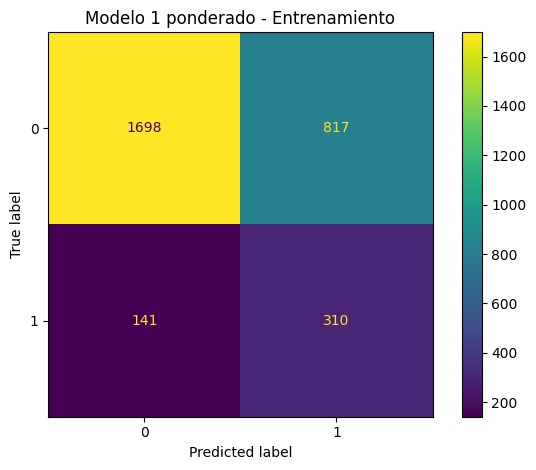

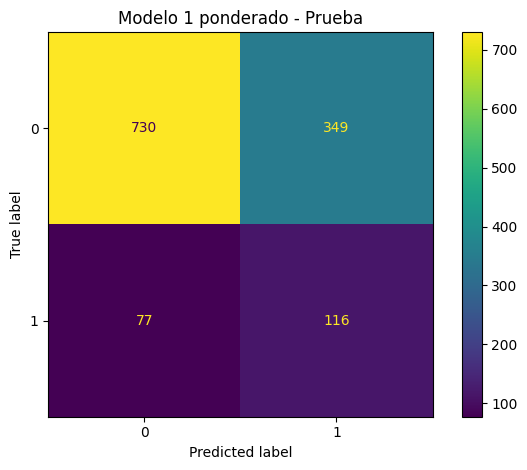

In [38]:
# ==========================================
# Matrices de confusión del Modelo 1
# ==========================================

cm_train_modelo1 = confusion_matrix(
    y_train,
    y_train_pred_modelo1
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_train_modelo1
).plot()

plt.title(
    "Modelo 1 ponderado - Entrenamiento"
)

plt.tight_layout()
plt.show()


cm_test_modelo1 = confusion_matrix(
    y_test,
    y_test_pred_modelo1
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_test_modelo1
).plot()

plt.title(
    "Modelo 1 ponderado - Prueba"
)

plt.tight_layout()
plt.show()

## Modelo 2 - Selección Backward Stepwise ponderada

El segundo modelo comienza con el conjunto completo de variables candidatas. Se aplica un procedimiento de eliminación hacia atrás, retirando en cada iteración la variable con el mayor p-valor cuando este supera el nivel de significancia de 0,05.

El modelo se ajusta mediante una regresión logística binomial ponderada, conservando el tratamiento aplicado al desbalance de clases.

In [39]:
# ==========================================
# Preparación de variables del Modelo 2
# ==========================================

variables_modelo2_iniciales = [
    "age",
    "sysBP",
    "diaBP",
    "totChol",
    "BMI",
    "glucose",
    "heartRate",
    "male",
    "currentSmoker"
]

variables_continuas_modelo2 = [
    "age",
    "sysBP",
    "diaBP",
    "totChol",
    "BMI",
    "glucose",
    "heartRate"
]

X_train_modelo2_base = (
    df_train_regresion[
        variables_modelo2_iniciales
    ]
    .copy()
)

X_test_modelo2_base = (
    df_test_regresion[
        variables_modelo2_iniciales
    ]
    .copy()
)

scaler_modelo2 = StandardScaler()

X_train_modelo2_scaled = (
    X_train_modelo2_base.copy()
)

X_test_modelo2_scaled = (
    X_test_modelo2_base.copy()
)

X_train_modelo2_scaled[
    variables_continuas_modelo2
] = scaler_modelo2.fit_transform(
    X_train_modelo2_scaled[
        variables_continuas_modelo2
    ]
)

X_test_modelo2_scaled[
    variables_continuas_modelo2
] = scaler_modelo2.transform(
    X_test_modelo2_scaled[
        variables_continuas_modelo2
    ]
)

print("Variables iniciales del Modelo 2:")
print(variables_modelo2_iniciales)

print("\nDimensión entrenamiento:")
print(X_train_modelo2_scaled.shape)

print("\nDimensión prueba:")
print(X_test_modelo2_scaled.shape)

assert X_train_modelo2_scaled.isna().sum().sum() == 0
assert X_test_modelo2_scaled.isna().sum().sum() == 0

print("\nPreparación completada correctamente.")

Variables iniciales del Modelo 2:
['age', 'sysBP', 'diaBP', 'totChol', 'BMI', 'glucose', 'heartRate', 'male', 'currentSmoker']

Dimensión entrenamiento:
(2966, 9)

Dimensión prueba:
(1272, 9)

Preparación completada correctamente.


In [40]:
# ==========================================
# Función Backward Stepwise ponderada
# ==========================================

def backward_stepwise_ponderado(
    X_entrenamiento,
    y_entrenamiento,
    pesos,
    alpha=0.05
):
    variables = list(
        X_entrenamiento.columns
    )

    historial = []

    iteracion = 1

    while True:

        X_iteracion = sm.add_constant(
            X_entrenamiento[variables],
            has_constant="add"
        )

        modelo_iteracion = sm.GLM(
            y_entrenamiento,
            X_iteracion,
            family=sm.families.Binomial(),
            freq_weights=pesos
        )

        resultado_iteracion = (
            modelo_iteracion.fit(
                maxiter=200
            )
        )

        p_valores = (
            resultado_iteracion
            .pvalues
            .drop(
                "const",
                errors="ignore"
            )
        )

        mayor_p_valor = p_valores.max()
        variable_mayor_p = p_valores.idxmax()

        historial.append({
            "Iteración": iteracion,
            "Variables": ", ".join(variables),
            "Mayor p-valor": mayor_p_valor,
            "Variable evaluada": variable_mayor_p,
            "AIC": resultado_iteracion.aic
        })

        if mayor_p_valor <= alpha:
            break

        variables.remove(
            variable_mayor_p
        )

        iteracion += 1

        if len(variables) == 0:
            raise ValueError(
                "El procedimiento eliminó "
                "todas las variables."
            )

    X_final = sm.add_constant(
        X_entrenamiento[variables],
        has_constant="add"
    )

    modelo_final = sm.GLM(
        y_entrenamiento,
        X_final,
        family=sm.families.Binomial(),
        freq_weights=pesos
    )

    resultado_final = modelo_final.fit(
        maxiter=200
    )

    historial = pd.DataFrame(
        historial
    )

    return (
        resultado_final,
        variables,
        historial
    )

In [41]:
# ==========================================
# Ejecución del Modelo 2
# ==========================================

(
    resultado2,
    variables_modelo2,
    historial_stepwise
) = backward_stepwise_ponderado(
    X_entrenamiento=(
        X_train_modelo2_scaled
    ),
    y_entrenamiento=y_train,
    pesos=pesos_train,
    alpha=0.05
)

print("=" * 60)
print("MODELO 2 - BACKWARD STEPWISE PONDERADO")
print("=" * 60)

print("\nVariables seleccionadas:")
print(variables_modelo2)

print("\nHistorial de eliminación:")

display(
    historial_stepwise[
        [
            "Iteración",
            "Variable evaluada",
            "Mayor p-valor",
            "AIC"
        ]
    ].round(4)
)

print("\nResumen final:")

print(
    resultado2.summary()
)

MODELO 2 - BACKWARD STEPWISE PONDERADO

Variables seleccionadas:
['age', 'sysBP', 'totChol', 'glucose', 'male', 'currentSmoker']

Historial de eliminación:


,Iteración,Variable evaluada,Mayor p-valor,AIC
0,1,heartRate,0.9880,3589.6165
1,2,diaBP,0.9883,3587.6167
2,3,BMI,0.3306,3585.6169
3,4,totChol,0.0017,3584.5655



Resumen final:
                 Generalized Linear Model Regression Results                  
Dep. Variable:             TenYearCHD   No. Observations:                 2966
Model:                            GLM   Df Residuals:                  2959.00
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1785.3
Date:                Thu, 16 Jul 2026   Deviance:                       3570.6
Time:                        11:36:05   Pearson chi2:                 2.97e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1668
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.6903      

In [42]:
# ==========================================
# Matrices finales del Modelo 2
# ==========================================

X_train_modelo2 = sm.add_constant(
    X_train_modelo2_scaled[
        variables_modelo2
    ],
    has_constant="add"
)

X_test_modelo2 = sm.add_constant(
    X_test_modelo2_scaled[
        variables_modelo2
    ],
    has_constant="add"
)

columnas_resultado2 = list(
    resultado2.params.index
)

X_train_modelo2 = (
    X_train_modelo2[
        columnas_resultado2
    ]
)

X_test_modelo2 = (
    X_test_modelo2[
        columnas_resultado2
    ]
)

assert list(
    X_train_modelo2.columns
) == columnas_resultado2

assert list(
    X_test_modelo2.columns
) == columnas_resultado2

print("Variables finales:")
print(variables_modelo2)

print("\nDimensión entrenamiento:")
print(X_train_modelo2.shape)

print("\nDimensión prueba:")
print(X_test_modelo2.shape)

Variables finales:
['age', 'sysBP', 'totChol', 'glucose', 'male', 'currentSmoker']

Dimensión entrenamiento:
(2966, 7)

Dimensión prueba:
(1272, 7)


In [43]:
# ==========================================
# Coeficientes y Odds Ratios del Modelo 2
# ==========================================

ic_modelo2 = resultado2.conf_int()

tabla_modelo2 = pd.DataFrame({
    "Variable": resultado2.params.index,
    "Coeficiente": resultado2.params.values,
    "Error estándar": resultado2.bse.values,
    "p-valor": resultado2.pvalues.values,
    "IC coef. inferior": ic_modelo2[0].values,
    "IC coef. superior": ic_modelo2[1].values
})

tabla_modelo2["Odds Ratio"] = np.exp(
    tabla_modelo2["Coeficiente"]
)

tabla_modelo2["IC OR inferior"] = np.exp(
    tabla_modelo2["IC coef. inferior"]
)

tabla_modelo2["IC OR superior"] = np.exp(
    tabla_modelo2["IC coef. superior"]
)

tabla_modelo2["Significativa 5 %"] = np.where(
    tabla_modelo2["p-valor"] < 0.05,
    "Sí",
    "No"
)

display(
    tabla_modelo2.round(4)
)

,Variable,Coeficiente,Error estándar,p-valor,IC coef. inferior,IC coef. superior,Odds Ratio,IC OR inferior,IC OR superior,Significativa 5 %
0,const,-0.6903,0.0696,0.0000,-0.8267,-0.5538,0.5014,0.4375,0.5748,Sí
1,age,0.6092,0.0465,0.0000,0.5181,0.7003,1.8389,1.6788,2.0143,Sí
2,sysBP,0.3761,0.0422,0.0000,0.2934,0.4589,1.4566,1.3409,1.5824,Sí
3,totChol,0.1253,0.0399,0.0017,0.0472,0.2034,1.1335,1.0483,1.2255,Sí
4,glucose,0.1605,0.0375,0.0000,0.0869,0.2340,1.1741,1.0908,1.2637,Sí
5,male,0.4838,0.0838,0.0000,0.3195,0.6481,1.6222,1.3765,1.9118,Sí
6,currentSmoker,0.4269,0.0868,0.0000,0.2568,0.5969,1.5324,1.2928,1.8165,Sí


In [44]:
# ==========================================
# Predicciones del Modelo 2
# ==========================================

y_train_prob_modelo2 = resultado2.predict(
    X_train_modelo2
)

y_test_prob_modelo2 = resultado2.predict(
    X_test_modelo2
)

y_train_pred_modelo2 = (
    y_train_prob_modelo2
    >= UMBRAL_CLASIFICACION
).astype(int)

y_test_pred_modelo2 = (
    y_test_prob_modelo2
    >= UMBRAL_CLASIFICACION
).astype(int)

print(
    "Positivos predichos en entrenamiento:",
    int(y_train_pred_modelo2.sum())
)

print(
    "Positivos predichos en prueba:",
    int(y_test_pred_modelo2.sum())
)

Positivos predichos en entrenamiento: 1116
Positivos predichos en prueba: 482


In [45]:
# ==========================================
# Métricas del Modelo 2
# ==========================================

metricas_modelo2 = pd.DataFrame([
    {
        "Modelo": "Modelo 2 - Stepwise ponderado",
        "Conjunto": "Entrenamiento",
        "Accuracy": accuracy_score(
            y_train,
            y_train_pred_modelo2
        ),
        "Precision": precision_score(
            y_train,
            y_train_pred_modelo2,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            y_train_pred_modelo2,
            zero_division=0
        ),
        "F1": f1_score(
            y_train,
            y_train_pred_modelo2,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_train,
            y_train_prob_modelo2
        )
    },
    {
        "Modelo": "Modelo 2 - Stepwise ponderado",
        "Conjunto": "Prueba",
        "Accuracy": accuracy_score(
            y_test,
            y_test_pred_modelo2
        ),
        "Precision": precision_score(
            y_test,
            y_test_pred_modelo2,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_test_pred_modelo2,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_test_pred_modelo2,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_test,
            y_test_prob_modelo2
        )
    }
])

metricas_modelo2[
    columnas_metricas
] = metricas_modelo2[
    columnas_metricas
].round(4)

display(metricas_modelo2)

,Modelo,Conjunto,Accuracy,Precision,Recall,F1,AUC
0,Modelo 2 - Stepwise ponderado,Entrenamiento,0.6814,0.2787,0.6896,0.3969,0.7374
1,Modelo 2 - Stepwise ponderado,Prueba,0.6612,0.2531,0.6321,0.3615,0.7025


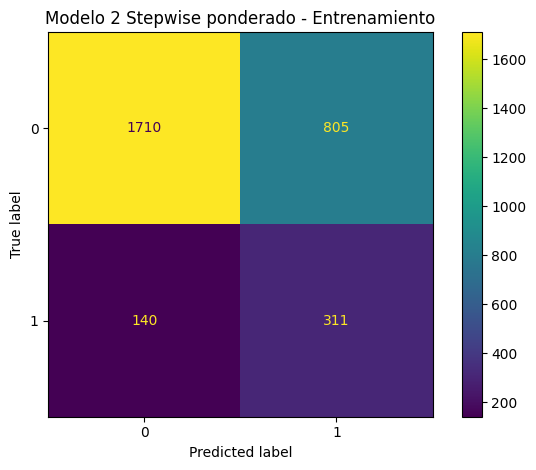

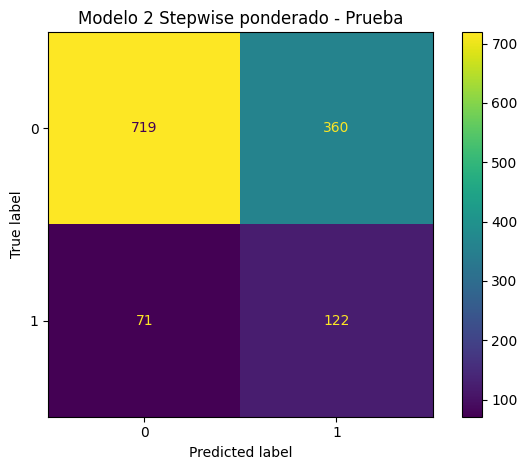

In [46]:
# ==========================================
# Matrices de confusión del Modelo 2
# ==========================================

cm_train_modelo2 = confusion_matrix(
    y_train,
    y_train_pred_modelo2
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_train_modelo2
).plot()

plt.title(
    "Modelo 2 Stepwise ponderado - Entrenamiento"
)

plt.tight_layout()
plt.show()


cm_test_modelo2 = confusion_matrix(
    y_test,
    y_test_pred_modelo2
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_test_modelo2
).plot()

plt.title(
    "Modelo 2 Stepwise ponderado - Prueba"
)

plt.tight_layout()
plt.show()

## Modelo 3 - Selección ponderada mediante AIC

El tercer modelo comienza con las nueve variables candidatas y aplica una eliminación hacia atrás basada en el criterio de información de Akaike.

En cada iteración se evalúa la eliminación de cada predictor. Una variable se retira únicamente cuando su exclusión reduce el AIC del modelo. El ajuste mantiene la ponderación utilizada para tratar el desbalance de clases.

Este procedimiento se diferencia del Modelo 2, porque la selección no depende directamente de los p-valores, sino del equilibrio entre ajuste y complejidad.

In [47]:
# ==========================================
# Selección backward ponderada mediante AIC
# ==========================================

def seleccion_backward_aic_ponderada(
    X_entrenamiento,
    y_entrenamiento,
    pesos
):
    variables = list(
        X_entrenamiento.columns
    )

    historial = []
    iteracion = 1

    while True:

        # Modelo actual
        X_actual = sm.add_constant(
            X_entrenamiento[variables],
            has_constant="add"
        )

        modelo_actual = sm.GLM(
            y_entrenamiento,
            X_actual,
            family=sm.families.Binomial(),
            freq_weights=pesos
        )

        resultado_actual = modelo_actual.fit(
            maxiter=200
        )

        aic_actual = resultado_actual.aic

        candidatos = []

        # Probar la eliminación de cada variable
        for variable in variables:

            variables_prueba = [
                columna
                for columna in variables
                if columna != variable
            ]

            if len(variables_prueba) == 0:
                continue

            X_prueba = sm.add_constant(
                X_entrenamiento[
                    variables_prueba
                ],
                has_constant="add"
            )

            modelo_prueba = sm.GLM(
                y_entrenamiento,
                X_prueba,
                family=sm.families.Binomial(),
                freq_weights=pesos
            )

            resultado_prueba = (
                modelo_prueba.fit(
                    maxiter=200
                )
            )

            candidatos.append({
                "Variable eliminada": variable,
                "Variables restantes": (
                    variables_prueba
                ),
                "AIC candidato": (
                    resultado_prueba.aic
                ),
                "Resultado": resultado_prueba
            })

        if len(candidatos) == 0:
            break

        mejor_candidato = min(
            candidatos,
            key=lambda elemento: (
                elemento["AIC candidato"]
            )
        )

        mejor_aic = (
            mejor_candidato[
                "AIC candidato"
            ]
        )

        variable_eliminada = (
            mejor_candidato[
                "Variable eliminada"
            ]
        )

        mejora_aic = (
            aic_actual - mejor_aic
        )

        historial.append({
            "Iteración": iteracion,
            "AIC actual": aic_actual,
            "Variable candidata a eliminar": (
                variable_eliminada
            ),
            "AIC después de eliminar": mejor_aic,
            "Mejora del AIC": mejora_aic,
            "Decisión": (
                "Eliminar"
                if mejor_aic < aic_actual
                else "Detener"
            )
        })

        # Solo se elimina cuando el AIC disminuye
        if mejor_aic < aic_actual:

            variables.remove(
                variable_eliminada
            )

            iteracion += 1

        else:
            break

    # Ajuste definitivo
    X_final = sm.add_constant(
        X_entrenamiento[variables],
        has_constant="add"
    )

    modelo_final = sm.GLM(
        y_entrenamiento,
        X_final,
        family=sm.families.Binomial(),
        freq_weights=pesos
    )

    resultado_final = modelo_final.fit(
        maxiter=200
    )

    historial = pd.DataFrame(
        historial
    )

    return (
        resultado_final,
        variables,
        historial
    )

In [48]:
# ==========================================
# Ejecución del Modelo 3 ponderado por AIC
# ==========================================

(
    resultado3,
    variables_modelo3,
    historial_aic
) = seleccion_backward_aic_ponderada(
    X_entrenamiento=(
        X_train_modelo2_scaled
    ),
    y_entrenamiento=y_train,
    pesos=pesos_train
)

print("=" * 60)
print("MODELO 3 - SELECCIÓN PONDERADA POR AIC")
print("=" * 60)

print("\nVariables seleccionadas:")
print(variables_modelo3)

print("\nHistorial de selección:")

display(
    historial_aic.round(4)
)

print("\nAIC final:")
print(round(resultado3.aic, 4))

if hasattr(resultado3, "bic_llf"):
    print("\nBIC final:")
    print(round(resultado3.bic_llf, 4))

print("\nResumen del modelo final:")

print(
    resultado3.summary()
)

MODELO 3 - SELECCIÓN PONDERADA POR AIC

Variables seleccionadas:
['age', 'sysBP', 'totChol', 'glucose', 'male', 'currentSmoker']

Historial de selección:


,Iteración,AIC actual,Variable candidata a eliminar,AIC después de eliminar,Mejora del AIC,Decisión
0,1,3589.6165,heartRate,3587.6167,1.9998,Eliminar
1,2,3587.6167,diaBP,3585.6169,1.9998,Eliminar
2,3,3585.6169,BMI,3584.5655,1.0514,Eliminar
3,4,3584.5655,totChol,3592.4926,-7.9272,Detener



AIC final:
3584.5655

BIC final:
3626.5303

Resumen del modelo final:
                 Generalized Linear Model Regression Results                  
Dep. Variable:             TenYearCHD   No. Observations:                 2966
Model:                            GLM   Df Residuals:                  2959.00
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1785.3
Date:                Thu, 16 Jul 2026   Deviance:                       3570.6
Time:                        11:42:32   Pearson chi2:                 2.97e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1668
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

In [49]:
# ==========================================
# Matrices finales del Modelo 3
# ==========================================

X_train_modelo3 = sm.add_constant(
    X_train_modelo2_scaled[
        variables_modelo3
    ],
    has_constant="add"
)

X_test_modelo3 = sm.add_constant(
    X_test_modelo2_scaled[
        variables_modelo3
    ],
    has_constant="add"
)

columnas_resultado3 = list(
    resultado3.params.index
)

X_train_modelo3 = (
    X_train_modelo3[
        columnas_resultado3
    ]
)

X_test_modelo3 = (
    X_test_modelo3[
        columnas_resultado3
    ]
)

assert list(
    X_train_modelo3.columns
) == columnas_resultado3

assert list(
    X_test_modelo3.columns
) == columnas_resultado3

print("Variables finales del Modelo 3:")
print(variables_modelo3)

print("\nDimensión entrenamiento:")
print(X_train_modelo3.shape)

print("\nDimensión prueba:")
print(X_test_modelo3.shape)

Variables finales del Modelo 3:
['age', 'sysBP', 'totChol', 'glucose', 'male', 'currentSmoker']

Dimensión entrenamiento:
(2966, 7)

Dimensión prueba:
(1272, 7)


In [50]:
# ==========================================
# Coeficientes y Odds Ratios del Modelo 3
# ==========================================

ic_modelo3 = resultado3.conf_int()

tabla_modelo3 = pd.DataFrame({
    "Variable": resultado3.params.index,
    "Coeficiente": resultado3.params.values,
    "Error estándar": resultado3.bse.values,
    "p-valor": resultado3.pvalues.values,
    "IC coef. inferior": ic_modelo3[0].values,
    "IC coef. superior": ic_modelo3[1].values
})

tabla_modelo3["Odds Ratio"] = np.exp(
    tabla_modelo3["Coeficiente"]
)

tabla_modelo3["IC OR inferior"] = np.exp(
    tabla_modelo3[
        "IC coef. inferior"
    ]
)

tabla_modelo3["IC OR superior"] = np.exp(
    tabla_modelo3[
        "IC coef. superior"
    ]
)

tabla_modelo3["Significativa 5 %"] = np.where(
    tabla_modelo3["p-valor"] < 0.05,
    "Sí",
    "No"
)

display(
    tabla_modelo3.round(4)
)

,Variable,Coeficiente,Error estándar,p-valor,IC coef. inferior,IC coef. superior,Odds Ratio,IC OR inferior,IC OR superior,Significativa 5 %
0,const,-0.6903,0.0696,0.0000,-0.8267,-0.5538,0.5014,0.4375,0.5748,Sí
1,age,0.6092,0.0465,0.0000,0.5181,0.7003,1.8389,1.6788,2.0143,Sí
2,sysBP,0.3761,0.0422,0.0000,0.2934,0.4589,1.4566,1.3409,1.5824,Sí
3,totChol,0.1253,0.0399,0.0017,0.0472,0.2034,1.1335,1.0483,1.2255,Sí
4,glucose,0.1605,0.0375,0.0000,0.0869,0.2340,1.1741,1.0908,1.2637,Sí
5,male,0.4838,0.0838,0.0000,0.3195,0.6481,1.6222,1.3765,1.9118,Sí
6,currentSmoker,0.4269,0.0868,0.0000,0.2568,0.5969,1.5324,1.2928,1.8165,Sí


In [51]:
# ==========================================
# Predicciones del Modelo 3
# ==========================================

y_train_prob_modelo3 = resultado3.predict(
    X_train_modelo3
)

y_test_prob_modelo3 = resultado3.predict(
    X_test_modelo3
)

y_train_pred_modelo3 = (
    y_train_prob_modelo3
    >= UMBRAL_CLASIFICACION
).astype(int)

y_test_pred_modelo3 = (
    y_test_prob_modelo3
    >= UMBRAL_CLASIFICACION
).astype(int)

print(
    "Positivos predichos en entrenamiento:",
    int(y_train_pred_modelo3.sum())
)

print(
    "Positivos predichos en prueba:",
    int(y_test_pred_modelo3.sum())
)

Positivos predichos en entrenamiento: 1116
Positivos predichos en prueba: 482


In [52]:
# ==========================================
# Métricas del Modelo 3
# ==========================================

metricas_modelo3 = pd.DataFrame([
    {
        "Modelo": "Modelo 3 - AIC ponderado",
        "Conjunto": "Entrenamiento",
        "Accuracy": accuracy_score(
            y_train,
            y_train_pred_modelo3
        ),
        "Precision": precision_score(
            y_train,
            y_train_pred_modelo3,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            y_train_pred_modelo3,
            zero_division=0
        ),
        "F1": f1_score(
            y_train,
            y_train_pred_modelo3,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_train,
            y_train_prob_modelo3
        )
    },
    {
        "Modelo": "Modelo 3 - AIC ponderado",
        "Conjunto": "Prueba",
        "Accuracy": accuracy_score(
            y_test,
            y_test_pred_modelo3
        ),
        "Precision": precision_score(
            y_test,
            y_test_pred_modelo3,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_test_pred_modelo3,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_test_pred_modelo3,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_test,
            y_test_prob_modelo3
        )
    }
])

metricas_modelo3[
    columnas_metricas
] = metricas_modelo3[
    columnas_metricas
].round(4)

display(metricas_modelo3)

,Modelo,Conjunto,Accuracy,Precision,Recall,F1,AUC
0,Modelo 3 - AIC ponderado,Entrenamiento,0.6814,0.2787,0.6896,0.3969,0.7374
1,Modelo 3 - AIC ponderado,Prueba,0.6612,0.2531,0.6321,0.3615,0.7025


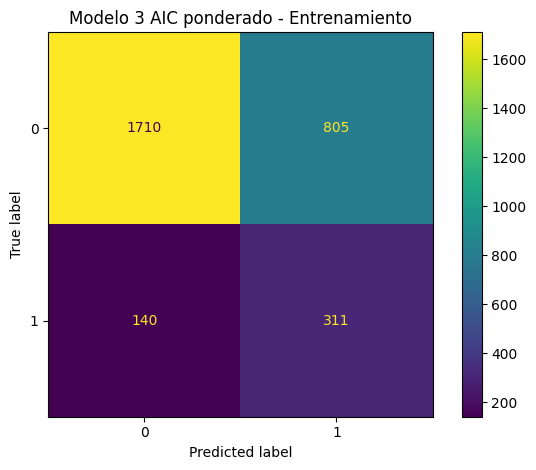

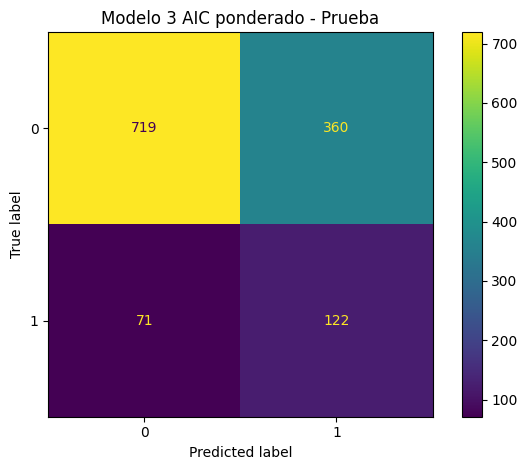

In [53]:
# ==========================================
# Matrices de confusión del Modelo 3
# ==========================================

cm_train_modelo3 = confusion_matrix(
    y_train,
    y_train_pred_modelo3
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_train_modelo3
).plot()

plt.title(
    "Modelo 3 AIC ponderado - Entrenamiento"
)

plt.tight_layout()
plt.show()


cm_test_modelo3 = confusion_matrix(
    y_test,
    y_test_pred_modelo3
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_test_modelo3
).plot()

plt.title(
    "Modelo 3 AIC ponderado - Prueba"
)

plt.tight_layout()
plt.show()

# Parte 3 - Comparación y selección del modelo final

Los tres modelos fueron ajustados utilizando la misma base con imputación por regresión, la misma partición de entrenamiento y prueba, la misma ponderación de clases y un umbral de clasificación de 0,50.

La comparación considera Accuracy, Precision, Recall, F1-score y AUC en entrenamiento y prueba. También se revisan AIC, BIC y cantidad de predictores para evaluar el equilibrio entre desempeño y parsimonia.

In [55]:
# ==========================================
# Comparación de métricas
# ==========================================

comparacion_metricas = pd.concat(
    [
        metricas_modelo1,
        metricas_modelo2,
        metricas_modelo3
    ],
    ignore_index=True
)

display(comparacion_metricas)

,Modelo,Conjunto,Accuracy,Precision,Recall,F1,AUC
0,Modelo 1 - S1/S2 ponderado,Entrenamiento,0.6770,0.2751,0.6874,0.3929,0.7309
1,Modelo 1 - S1/S2 ponderado,Prueba,0.6651,0.2495,0.6010,0.3526,0.6980
2,Modelo 2 - Stepwise ponderado,Entrenamiento,0.6814,0.2787,0.6896,0.3969,0.7374
3,Modelo 2 - Stepwise ponderado,Prueba,0.6612,0.2531,0.6321,0.3615,0.7025
4,Modelo 3 - AIC ponderado,Entrenamiento,0.6814,0.2787,0.6896,0.3969,0.7374
5,Modelo 3 - AIC ponderado,Prueba,0.6612,0.2531,0.6321,0.3615,0.7025


In [56]:
# ==========================================
# Comparación de ajuste y parsimonia
# ==========================================

def obtener_bic(resultado):

    if hasattr(resultado, "bic_llf"):
        return resultado.bic_llf

    return resultado.bic


comparacion_ajuste = pd.DataFrame([
    {
        "Modelo": "Modelo 1 - S1/S2 ponderado",
        "Cantidad de predictores": (
            len(resultado1.params) - 1
        ),
        "Variables": ", ".join(
            [
                variable
                for variable in resultado1.params.index
                if variable != "const"
            ]
        ),
        "AIC": resultado1.aic,
        "BIC": obtener_bic(resultado1)
    },
    {
        "Modelo": "Modelo 2 - Stepwise ponderado",
        "Cantidad de predictores": (
            len(resultado2.params) - 1
        ),
        "Variables": ", ".join(
            variables_modelo2
        ),
        "AIC": resultado2.aic,
        "BIC": obtener_bic(resultado2)
    },
    {
        "Modelo": "Modelo 3 - AIC ponderado",
        "Cantidad de predictores": (
            len(resultado3.params) - 1
        ),
        "Variables": ", ".join(
            variables_modelo3
        ),
        "AIC": resultado3.aic,
        "BIC": obtener_bic(resultado3)
    }
])

comparacion_ajuste[
    ["AIC", "BIC"]
] = comparacion_ajuste[
    ["AIC", "BIC"]
].round(4)

display(comparacion_ajuste)

,Modelo,Cantidad de predictores,Variables,AIC,BIC
0,Modelo 1 - S1/S2 ponderado,6,"age, sysBP, diaBP, BMI, glucose, male",3619.6927,3661.6575
1,Modelo 2 - Stepwise ponderado,6,"age, sysBP, totChol, glucose, male, currentSmoker",3584.5655,3626.5303
2,Modelo 3 - AIC ponderado,6,"age, sysBP, totChol, glucose, male, currentSmoker",3584.5655,3626.5303


In [57]:
# ==========================================
# Comparación definitiva en prueba
# ==========================================

comparacion_prueba = (
    comparacion_metricas[
        comparacion_metricas["Conjunto"] == "Prueba"
    ]
    .merge(
        comparacion_ajuste,
        on="Modelo",
        how="left"
    )
)

comparacion_prueba = (
    comparacion_prueba
    .sort_values(
        by=[
            "AUC",
            "F1",
            "Recall",
            "Cantidad de predictores",
            "AIC"
        ],
        ascending=[
            False,
            False,
            False,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

display(comparacion_prueba)

print("=" * 60)
print("MODELO MEJOR POSICIONADO PRELIMINARMENTE")
print("=" * 60)

print(
    comparacion_prueba.loc[0, "Modelo"]
)

,Modelo,Conjunto,Accuracy,Precision,Recall,F1,AUC,Cantidad de predictores,Variables,AIC,BIC
0,Modelo 2 - Stepwise ponderado,Prueba,0.6612,0.2531,0.6321,0.3615,0.7025,6,"age, sysBP, totChol, glucose, male, currentSmoker",3584.5655,3626.5303
1,Modelo 3 - AIC ponderado,Prueba,0.6612,0.2531,0.6321,0.3615,0.7025,6,"age, sysBP, totChol, glucose, male, currentSmoker",3584.5655,3626.5303
2,Modelo 1 - S1/S2 ponderado,Prueba,0.6651,0.2495,0.6010,0.3526,0.6980,6,"age, sysBP, diaBP, BMI, glucose, male",3619.6927,3661.6575


MODELO MEJOR POSICIONADO PRELIMINARMENTE
Modelo 2 - Stepwise ponderado


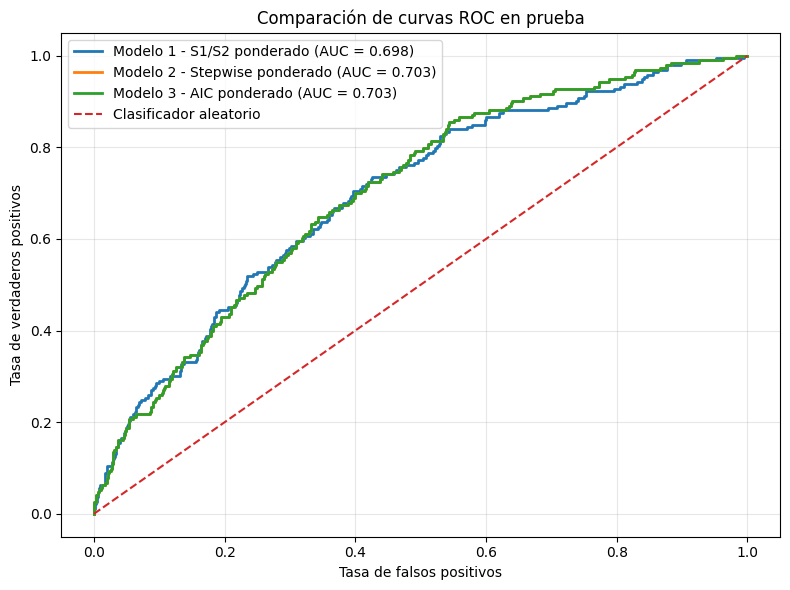

In [58]:
# ==========================================
# Curvas ROC en el conjunto de prueba
# ==========================================

modelos_roc = {
    "Modelo 1 - S1/S2 ponderado": (
        y_test_prob_modelo1
    ),
    "Modelo 2 - Stepwise ponderado": (
        y_test_prob_modelo2
    ),
    "Modelo 3 - AIC ponderado": (
        y_test_prob_modelo3
    )
}

plt.figure(figsize=(8, 6))

for nombre_modelo, probabilidades in modelos_roc.items():

    fpr_modelo, tpr_modelo, _ = roc_curve(
        y_test,
        probabilidades
    )

    auc_modelo = roc_auc_score(
        y_test,
        probabilidades
    )

    plt.plot(
        fpr_modelo,
        tpr_modelo,
        linewidth=2,
        label=(
            f"{nombre_modelo} "
            f"(AUC = {auc_modelo:.3f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title(
    "Comparación de curvas ROC en prueba"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [59]:
# ==========================================
# Estabilidad entre entrenamiento y prueba
# ==========================================

metricas_train = (
    comparacion_metricas[
        comparacion_metricas["Conjunto"]
        == "Entrenamiento"
    ]
    .set_index("Modelo")
)

metricas_test = (
    comparacion_metricas[
        comparacion_metricas["Conjunto"]
        == "Prueba"
    ]
    .set_index("Modelo")
)

comparacion_estabilidad = pd.DataFrame({
    "AUC entrenamiento": metricas_train["AUC"],
    "AUC prueba": metricas_test["AUC"],
    "Diferencia AUC": abs(
        metricas_train["AUC"]
        - metricas_test["AUC"]
    ),
    "F1 entrenamiento": metricas_train["F1"],
    "F1 prueba": metricas_test["F1"],
    "Diferencia F1": abs(
        metricas_train["F1"]
        - metricas_test["F1"]
    )
}).reset_index()

display(
    comparacion_estabilidad.round(4)
)

,Modelo,AUC entrenamiento,AUC prueba,Diferencia AUC,F1 entrenamiento,F1 prueba,Diferencia F1
0,Modelo 1 - S1/S2 ponderado,0.7309,0.6980,0.0329,0.3929,0.3526,0.0403
1,Modelo 2 - Stepwise ponderado,0.7374,0.7025,0.0349,0.3969,0.3615,0.0354
2,Modelo 3 - AIC ponderado,0.7374,0.7025,0.0349,0.3969,0.3615,0.0354


In [60]:
# ==========================================
# Validación de la comparación de modelos
# ==========================================

print("Filas de métricas:", len(comparacion_metricas))
print("Modelos en prueba:", len(comparacion_prueba))
print("Modelos en ajuste:", len(comparacion_ajuste))

print("\nModelos disponibles:")
print(
    comparacion_prueba[
        [
            "Modelo",
            "AUC",
            "F1",
            "Recall",
            "Cantidad de predictores",
            "AIC"
        ]
    ]
)

assert len(comparacion_metricas) == 6
assert len(comparacion_prueba) == 3
assert len(comparacion_ajuste) == 3

print("\nValidación correcta.")

Filas de métricas: 6
Modelos en prueba: 3
Modelos en ajuste: 3

Modelos disponibles:
                          Modelo     AUC      F1  Recall  \
0  Modelo 2 - Stepwise ponderado  0.7025  0.3615  0.6321   
1       Modelo 3 - AIC ponderado  0.7025  0.3615  0.6321   
2     Modelo 1 - S1/S2 ponderado  0.6980  0.3526  0.6010   

   Cantidad de predictores        AIC  
0                        6  3584.5655  
1                        6  3584.5655  
2                        6  3619.6927  

Validación correcta.


In [61]:
# ==========================================
# Selección del modelo final
# ==========================================

fila_modelo_final = (
    comparacion_prueba
    .iloc[0]
)

nombre_modelo_final = (
    fila_modelo_final["Modelo"]
)

print("=" * 65)
print("MODELO FINAL MEJOR POSICIONADO")
print("=" * 65)

print("Modelo:", nombre_modelo_final)

print(
    "AUC de prueba:",
    fila_modelo_final["AUC"]
)

print(
    "F1 de prueba:",
    fila_modelo_final["F1"]
)

print(
    "Recall de prueba:",
    fila_modelo_final["Recall"]
)

print(
    "Accuracy de prueba:",
    fila_modelo_final["Accuracy"]
)

print(
    "Cantidad de predictores:",
    int(
        fila_modelo_final[
            "Cantidad de predictores"
        ]
    )
)

print(
    "AIC:",
    fila_modelo_final["AIC"]
)

print(
    "Variables:",
    fila_modelo_final["Variables"]
)

MODELO FINAL MEJOR POSICIONADO
Modelo: Modelo 2 - Stepwise ponderado
AUC de prueba: 0.7025
F1 de prueba: 0.3615
Recall de prueba: 0.6321
Accuracy de prueba: 0.6612
Cantidad de predictores: 6
AIC: 3584.5655
Variables: age, sysBP, totChol, glucose, male, currentSmoker


In [62]:
# ==========================================
# Objetos correspondientes a cada modelo
# ==========================================

modelos_disponibles = {
    "Modelo 1 - S1/S2 ponderado": {
        "resultado": resultado1,
        "variables": variables_modelo1,
        "X_train": X_train_modelo1,
        "X_test": X_test_modelo1,
        "prob_train": y_train_prob_modelo1,
        "prob_test": y_test_prob_modelo1,
        "pred_train": y_train_pred_modelo1,
        "pred_test": y_test_pred_modelo1
    },

    "Modelo 2 - Stepwise ponderado": {
        "resultado": resultado2,
        "variables": variables_modelo2,
        "X_train": X_train_modelo2,
        "X_test": X_test_modelo2,
        "prob_train": y_train_prob_modelo2,
        "prob_test": y_test_prob_modelo2,
        "pred_train": y_train_pred_modelo2,
        "pred_test": y_test_pred_modelo2
    },

    "Modelo 3 - AIC ponderado": {
        "resultado": resultado3,
        "variables": variables_modelo3,
        "X_train": X_train_modelo3,
        "X_test": X_test_modelo3,
        "prob_train": y_train_prob_modelo3,
        "prob_test": y_test_prob_modelo3,
        "pred_train": y_train_pred_modelo3,
        "pred_test": y_test_pred_modelo3
    }
}

seleccion_final = modelos_disponibles[
    nombre_modelo_final
]

modelo_final = seleccion_final[
    "resultado"
]

variables_finales = seleccion_final[
    "variables"
]

X_train_final = seleccion_final[
    "X_train"
].copy()

X_test_final = seleccion_final[
    "X_test"
].copy()

y_train_prob_final = seleccion_final[
    "prob_train"
]

y_test_prob_final = seleccion_final[
    "prob_test"
]

y_train_pred_final = seleccion_final[
    "pred_train"
]

y_test_pred_final = seleccion_final[
    "pred_test"
]

print("=" * 65)
print("CONFIGURACIÓN DEL MODELO FINAL")
print("=" * 65)

print("Modelo:", nombre_modelo_final)
print("Variables:", variables_finales)

print(
    "AIC:",
    round(modelo_final.aic, 4)
)

print(
    "AUC prueba:",
    round(
        roc_auc_score(
            y_test,
            y_test_prob_final
        ),
        4
    )
)

assert list(
    X_train_final.columns
) == list(
    modelo_final.params.index
)

assert list(
    X_test_final.columns
) == list(
    modelo_final.params.index
)

print("\nConfiguración validada correctamente.")

CONFIGURACIÓN DEL MODELO FINAL
Modelo: Modelo 2 - Stepwise ponderado
Variables: ['age', 'sysBP', 'totChol', 'glucose', 'male', 'currentSmoker']
AIC: 3584.5655
AUC prueba: 0.7025

Configuración validada correctamente.


In [63]:
# ==========================================
# Resultado definitivo del modelo final
# ==========================================

ic_final = modelo_final.conf_int()

tabla_modelo_final = pd.DataFrame({
    "Variable": modelo_final.params.index,
    "Coeficiente": modelo_final.params.values,
    "Error estándar": modelo_final.bse.values,
    "p-valor": modelo_final.pvalues.values,
    "IC coef. inferior": ic_final[0].values,
    "IC coef. superior": ic_final[1].values
})

tabla_modelo_final["Odds Ratio"] = np.exp(
    tabla_modelo_final["Coeficiente"]
)

tabla_modelo_final["IC OR inferior"] = np.exp(
    tabla_modelo_final[
        "IC coef. inferior"
    ]
)

tabla_modelo_final["IC OR superior"] = np.exp(
    tabla_modelo_final[
        "IC coef. superior"
    ]
)

tabla_modelo_final[
    "Significativa 5 %"
] = np.where(
    tabla_modelo_final["p-valor"] < 0.05,
    "Sí",
    "No"
)

display(
    tabla_modelo_final.round(4)
)

,Variable,Coeficiente,Error estándar,p-valor,IC coef. inferior,IC coef. superior,Odds Ratio,IC OR inferior,IC OR superior,Significativa 5 %
0,const,-0.6903,0.0696,0.0000,-0.8267,-0.5538,0.5014,0.4375,0.5748,Sí
1,age,0.6092,0.0465,0.0000,0.5181,0.7003,1.8389,1.6788,2.0143,Sí
2,sysBP,0.3761,0.0422,0.0000,0.2934,0.4589,1.4566,1.3409,1.5824,Sí
3,totChol,0.1253,0.0399,0.0017,0.0472,0.2034,1.1335,1.0483,1.2255,Sí
4,glucose,0.1605,0.0375,0.0000,0.0869,0.2340,1.1741,1.0908,1.2637,Sí
5,male,0.4838,0.0838,0.0000,0.3195,0.6481,1.6222,1.3765,1.9118,Sí
6,currentSmoker,0.4269,0.0868,0.0000,0.2568,0.5969,1.5324,1.2928,1.8165,Sí


In [64]:
# ==========================================
# Métricas definitivas del modelo final
# ==========================================

metricas_modelo_final = pd.DataFrame([
    {
        "Conjunto": "Entrenamiento",
        "Accuracy": accuracy_score(
            y_train,
            y_train_pred_final
        ),
        "Precision": precision_score(
            y_train,
            y_train_pred_final,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            y_train_pred_final,
            zero_division=0
        ),
        "F1": f1_score(
            y_train,
            y_train_pred_final,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_train,
            y_train_prob_final
        )
    },
    {
        "Conjunto": "Prueba",
        "Accuracy": accuracy_score(
            y_test,
            y_test_pred_final
        ),
        "Precision": precision_score(
            y_test,
            y_test_pred_final,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_test_pred_final,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_test_pred_final,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_test,
            y_test_prob_final
        )
    }
])

metricas_modelo_final[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC"
    ]
] = metricas_modelo_final[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC"
    ]
].round(4)

print(
    "Modelo seleccionado:",
    nombre_modelo_final
)

display(
    metricas_modelo_final
)

Modelo seleccionado: Modelo 2 - Stepwise ponderado


,Conjunto,Accuracy,Precision,Recall,F1,AUC
0,Entrenamiento,0.6814,0.2787,0.6896,0.3969,0.7374
1,Prueba,0.6612,0.2531,0.6321,0.3615,0.7025


# Parte 4 - Evaluación de estabilidad mediante Bootstrap

Se evalúa la estabilidad del modelo final mediante bootstrap no paramétrico de filas. En cada remuestra se seleccionan observaciones del conjunto de entrenamiento con reemplazo y se vuelve a ajustar el modelo logístico ponderado.

La especificación del modelo final permanece fija para estudiar la variabilidad de sus coeficientes. Los pesos de clase se recalculan dentro de cada remuestra para conservar el tratamiento del desbalance.

Se utilizarán 10.000 remuestras y se construirán intervalos de confianza percentiles del 95 % para los coeficientes y Odds Ratios. Estos resultados se compararán con los intervalos tradicionales de Wald.

In [65]:
# ==========================================
# Verificación previa al bootstrap
# ==========================================

print("=" * 65)
print("MODELO QUE SERÁ EVALUADO MEDIANTE BOOTSTRAP")
print("=" * 65)

print("Modelo:", nombre_modelo_final)
print("Variables:", variables_finales)

print("\nDimensión de X_train_final:")
print(X_train_final.shape)

print("\nCantidad de observaciones de y_train:")
print(len(y_train))

print("\nColumnas del modelo:")
print(list(X_train_final.columns))

assert len(X_train_final) == len(y_train)

assert list(
    X_train_final.columns
) == list(
    modelo_final.params.index
)

assert X_train_final.isna().sum().sum() == 0

print("\nVerificación completada correctamente.")

MODELO QUE SERÁ EVALUADO MEDIANTE BOOTSTRAP
Modelo: Modelo 2 - Stepwise ponderado
Variables: ['age', 'sysBP', 'totChol', 'glucose', 'male', 'currentSmoker']

Dimensión de X_train_final:
(2966, 7)

Cantidad de observaciones de y_train:
2966

Columnas del modelo:
['const', 'age', 'sysBP', 'totChol', 'glucose', 'male', 'currentSmoker']

Verificación completada correctamente.


In [66]:
# ==========================================
# Función bootstrap ponderada para GLM
# ==========================================

import warnings

from statsmodels.tools.sm_exceptions import (
    ConvergenceWarning
)


def bootstrap_glm_ponderado(
    X,
    y,
    numero_remuestras,
    semilla=42,
    parametros_iniciales=None
):
    """
    Realiza bootstrap de filas para un modelo
    logístico binomial ponderado.

    Los pesos de clase se recalculan en cada
    remuestra.
    """

    # Alinear y con las filas de X
    y_alineado = y.loc[X.index]

    X_array = X.to_numpy(dtype=float)
    y_array = y_alineado.to_numpy(dtype=int)

    nombres_columnas = list(X.columns)

    numero_observaciones = len(y_array)

    generador = np.random.default_rng(
        semilla
    )

    coeficientes_validos = []

    numero_intentos = 0
    numero_fallos = 0

    maximo_intentos = int(
        numero_remuestras * 1.20
    )

    progreso_cada = max(
        1,
        numero_remuestras // 20
    )

    while (
        len(coeficientes_validos)
        < numero_remuestras
        and numero_intentos
        < maximo_intentos
    ):

        numero_intentos += 1

        indices_bootstrap = (
            generador.integers(
                low=0,
                high=numero_observaciones,
                size=numero_observaciones
            )
        )

        X_bootstrap = X_array[
            indices_bootstrap
        ]

        y_bootstrap = y_array[
            indices_bootstrap
        ]

        conteos_clase = np.bincount(
            y_bootstrap,
            minlength=2
        )

        # Evitar una remuestra con una sola clase
        if np.any(conteos_clase == 0):
            numero_fallos += 1
            continue

        numero_clase_0 = conteos_clase[0]
        numero_clase_1 = conteos_clase[1]

        pesos_bootstrap = np.where(
            y_bootstrap == 0,
            numero_observaciones
            / (2 * numero_clase_0),
            numero_observaciones
            / (2 * numero_clase_1)
        )

        try:

            modelo_bootstrap = sm.GLM(
                y_bootstrap,
                X_bootstrap,
                family=sm.families.Binomial(),
                freq_weights=pesos_bootstrap
            )

            with warnings.catch_warnings():

                warnings.simplefilter(
                    "ignore",
                    ConvergenceWarning
                )

                resultado_bootstrap = (
                    modelo_bootstrap.fit(
                        start_params=(
                            parametros_iniciales
                        ),
                        maxiter=100,
                        disp=0
                    )
                )

            parametros_bootstrap = (
                np.asarray(
                    resultado_bootstrap.params,
                    dtype=float
                )
            )

            if np.all(
                np.isfinite(
                    parametros_bootstrap
                )
            ):
                coeficientes_validos.append(
                    parametros_bootstrap
                )
            else:
                numero_fallos += 1

        except Exception:
            numero_fallos += 1

        if (
            len(coeficientes_validos)
            > 0
            and len(coeficientes_validos)
            % progreso_cada == 0
        ):
            print(
                "Remuestras válidas:",
                len(coeficientes_validos),
                "/",
                numero_remuestras
            )

    if (
        len(coeficientes_validos)
        < numero_remuestras
    ):
        raise RuntimeError(
            "No fue posible completar todas "
            "las remuestras solicitadas. "
            f"Se obtuvieron "
            f"{len(coeficientes_validos)} "
            "remuestras válidas."
        )

    tabla_coeficientes = pd.DataFrame(
        coeficientes_validos,
        columns=nombres_columnas
    )

    return (
        tabla_coeficientes,
        numero_intentos,
        numero_fallos
    )

In [67]:
# ==========================================
# Prueba del bootstrap con 100 remuestras
# ==========================================

import time

inicio_prueba_bootstrap = time.time()

(
    bootstrap_prueba,
    intentos_prueba,
    fallos_prueba
) = bootstrap_glm_ponderado(
    X=X_train_final,
    y=y_train,
    numero_remuestras=100,
    semilla=SEED,
    parametros_iniciales=(
        modelo_final.params.values
    )
)

tiempo_prueba_bootstrap = (
    time.time()
    - inicio_prueba_bootstrap
)

estimacion_minutos_10000 = (
    tiempo_prueba_bootstrap
    * 100
    / 60
)

print("=" * 65)
print("PRUEBA DEL BOOTSTRAP COMPLETADA")
print("=" * 65)

print(
    "Remuestras válidas:",
    len(bootstrap_prueba)
)

print(
    "Número de intentos:",
    intentos_prueba
)

print(
    "Ajustes fallidos:",
    fallos_prueba
)

print(
    "Dimensión del resultado:",
    bootstrap_prueba.shape
)

print(
    "Tiempo de prueba en segundos:",
    round(
        tiempo_prueba_bootstrap,
        2
    )
)

print(
    "Tiempo estimado para 10.000 "
    "remuestras en minutos:",
    round(
        estimacion_minutos_10000,
        2
    )
)

display(
    bootstrap_prueba.head()
)

Remuestras válidas: 5 / 100
Remuestras válidas: 10 / 100
Remuestras válidas: 15 / 100
Remuestras válidas: 20 / 100
Remuestras válidas: 25 / 100
Remuestras válidas: 30 / 100
Remuestras válidas: 35 / 100
Remuestras válidas: 40 / 100
Remuestras válidas: 45 / 100
Remuestras válidas: 50 / 100
Remuestras válidas: 55 / 100
Remuestras válidas: 60 / 100
Remuestras válidas: 65 / 100
Remuestras válidas: 70 / 100
Remuestras válidas: 75 / 100
Remuestras válidas: 80 / 100
Remuestras válidas: 85 / 100
Remuestras válidas: 90 / 100
Remuestras válidas: 95 / 100
Remuestras válidas: 100 / 100
PRUEBA DEL BOOTSTRAP COMPLETADA
Remuestras válidas: 100
Número de intentos: 100
Ajustes fallidos: 0
Dimensión del resultado: (100, 7)
Tiempo de prueba en segundos: 0.54
Tiempo estimado para 10.000 remuestras en minutos: 0.89


,const,age,sysBP,totChol,glucose,male,currentSmoker
0,-0.537545,0.547595,0.436158,0.151474,0.202673,0.434470,0.152639
1,-0.805613,0.606143,0.522856,0.145713,0.135123,0.625240,0.510854
2,-0.582174,0.557826,0.295661,0.087714,0.183532,0.338341,0.476313
3,-0.673986,0.619099,0.395661,0.108599,0.114339,0.266121,0.593568
4,-0.707634,0.671483,0.362057,0.142023,0.169499,0.647647,0.309928


In [68]:
# ==========================================
# Bootstrap definitivo: 10.000 remuestras
# ==========================================

inicio_bootstrap = time.time()

(
    bootstrap_coeficientes,
    intentos_bootstrap,
    fallos_bootstrap
) = bootstrap_glm_ponderado(
    X=X_train_final,
    y=y_train,
    numero_remuestras=10000,
    semilla=SEED,
    parametros_iniciales=(
        modelo_final.params.values
    )
)

tiempo_bootstrap = (
    time.time()
    - inicio_bootstrap
)

print("=" * 65)
print("BOOTSTRAP DEFINITIVO COMPLETADO")
print("=" * 65)

print(
    "Remuestras válidas:",
    len(bootstrap_coeficientes)
)

print(
    "Número total de intentos:",
    intentos_bootstrap
)

print(
    "Ajustes fallidos:",
    fallos_bootstrap
)

print(
    "Dimensión del resultado:",
    bootstrap_coeficientes.shape
)

print(
    "Tiempo total en segundos:",
    round(tiempo_bootstrap, 2)
)

print(
    "Tiempo total en minutos:",
    round(tiempo_bootstrap / 60, 2)
)

display(
    bootstrap_coeficientes.head()
)

Remuestras válidas: 500 / 10000
Remuestras válidas: 1000 / 10000
Remuestras válidas: 1500 / 10000
Remuestras válidas: 2000 / 10000
Remuestras válidas: 2500 / 10000
Remuestras válidas: 3000 / 10000
Remuestras válidas: 3500 / 10000
Remuestras válidas: 4000 / 10000
Remuestras válidas: 4500 / 10000
Remuestras válidas: 5000 / 10000
Remuestras válidas: 5500 / 10000
Remuestras válidas: 6000 / 10000
Remuestras válidas: 6500 / 10000
Remuestras válidas: 7000 / 10000
Remuestras válidas: 7500 / 10000
Remuestras válidas: 8000 / 10000
Remuestras válidas: 8500 / 10000
Remuestras válidas: 9000 / 10000
Remuestras válidas: 9500 / 10000
Remuestras válidas: 10000 / 10000
BOOTSTRAP DEFINITIVO COMPLETADO
Remuestras válidas: 10000
Número total de intentos: 10000
Ajustes fallidos: 0
Dimensión del resultado: (10000, 7)
Tiempo total en segundos: 60.63
Tiempo total en minutos: 1.01


,const,age,sysBP,totChol,glucose,male,currentSmoker
0,-0.537545,0.547595,0.436158,0.151474,0.202673,0.434470,0.152639
1,-0.805613,0.606143,0.522856,0.145713,0.135123,0.625240,0.510854
2,-0.582174,0.557826,0.295661,0.087714,0.183532,0.338341,0.476313
3,-0.673986,0.619099,0.395661,0.108599,0.114339,0.266121,0.593568
4,-0.707634,0.671483,0.362057,0.142023,0.169499,0.647647,0.309928


In [69]:
# ==========================================
# Intervalos percentiles bootstrap del 95 %
# ==========================================

resumen_bootstrap = pd.DataFrame({
    "Variable": bootstrap_coeficientes.columns,

    "Coeficiente original": [
        modelo_final.params[
            variable
        ]
        for variable in bootstrap_coeficientes.columns
    ],

    "Media bootstrap": (
        bootstrap_coeficientes
        .mean()
        .values
    ),

    "Mediana bootstrap": (
        bootstrap_coeficientes
        .median()
        .values
    ),

    "Error estándar bootstrap": (
        bootstrap_coeficientes
        .std(ddof=1)
        .values
    ),

    "IC bootstrap inferior": (
        bootstrap_coeficientes
        .quantile(0.025)
        .values
    ),

    "IC bootstrap superior": (
        bootstrap_coeficientes
        .quantile(0.975)
        .values
    )
})

resumen_bootstrap["Sesgo bootstrap"] = (
    resumen_bootstrap["Media bootstrap"]
    - resumen_bootstrap["Coeficiente original"]
)

resumen_bootstrap["Odds Ratio original"] = np.exp(
    resumen_bootstrap["Coeficiente original"]
)

resumen_bootstrap["OR bootstrap inferior"] = np.exp(
    resumen_bootstrap["IC bootstrap inferior"]
)

resumen_bootstrap["OR bootstrap superior"] = np.exp(
    resumen_bootstrap["IC bootstrap superior"]
)

resumen_bootstrap[
    "Significativa según bootstrap"
] = np.where(
    (
        resumen_bootstrap[
            "IC bootstrap inferior"
        ] > 0
    )
    |
    (
        resumen_bootstrap[
            "IC bootstrap superior"
        ] < 0
    ),
    "Sí",
    "No"
)

display(
    resumen_bootstrap.round(4)
)

,Variable,Coeficiente original,Media bootstrap,Mediana bootstrap,Error estándar bootstrap,IC bootstrap inferior,IC bootstrap superior,Sesgo bootstrap,Odds Ratio original,OR bootstrap inferior,OR bootstrap superior,Significativa según bootstrap
0,const,-0.6903,-0.6983,-0.6960,0.0896,-0.8788,-0.5291,-0.0080,0.5014,0.4153,0.5891,Sí
1,age,0.6092,0.6112,0.6103,0.0615,0.4944,0.7356,0.0020,1.8389,1.6395,2.0868,Sí
2,sysBP,0.3761,0.3783,0.3780,0.0564,0.2669,0.4888,0.0022,1.4566,1.3060,1.6304,Sí
3,totChol,0.1253,0.1244,0.1239,0.0583,0.0087,0.2388,-0.0009,1.1335,1.0087,1.2697,Sí
4,glucose,0.1605,0.1613,0.1613,0.0467,0.0683,0.2539,0.0008,1.1741,1.0706,1.2891,Sí
5,male,0.4838,0.4854,0.4848,0.1196,0.2471,0.7205,0.0016,1.6222,1.2803,2.0555,Sí
6,currentSmoker,0.4269,0.4295,0.4279,0.1223,0.1928,0.6717,0.0026,1.5324,1.2126,1.9576,Sí


In [70]:
# ==========================================
# Comparación Wald frente a Bootstrap
# ==========================================

intervalos_wald = modelo_final.conf_int()

comparacion_intervalos = pd.DataFrame({
    "Variable": modelo_final.params.index,

    "Coeficiente": (
        modelo_final.params.values
    ),

    "IC Wald inferior": (
        intervalos_wald[0].values
    ),

    "IC Wald superior": (
        intervalos_wald[1].values
    )
})

comparacion_intervalos = (
    comparacion_intervalos
    .merge(
        resumen_bootstrap[
            [
                "Variable",
                "IC bootstrap inferior",
                "IC bootstrap superior",
                "Error estándar bootstrap",
                "Sesgo bootstrap"
            ]
        ],
        on="Variable",
        how="left"
    )
)

comparacion_intervalos[
    "Ancho IC Wald"
] = (
    comparacion_intervalos[
        "IC Wald superior"
    ]
    - comparacion_intervalos[
        "IC Wald inferior"
    ]
)

comparacion_intervalos[
    "Ancho IC bootstrap"
] = (
    comparacion_intervalos[
        "IC bootstrap superior"
    ]
    - comparacion_intervalos[
        "IC bootstrap inferior"
    ]
)

comparacion_intervalos[
    "Conclusión bootstrap"
] = np.where(
    (
        comparacion_intervalos[
            "IC bootstrap inferior"
        ] > 0
    )
    |
    (
        comparacion_intervalos[
            "IC bootstrap superior"
        ] < 0
    ),
    "Efecto estable",
    "Efecto no concluyente"
)

display(
    comparacion_intervalos.round(4)
)

,Variable,Coeficiente,IC Wald inferior,IC Wald superior,IC bootstrap inferior,IC bootstrap superior,Error estándar bootstrap,Sesgo bootstrap,Ancho IC Wald,Ancho IC bootstrap,Conclusión bootstrap
0,const,-0.6903,-0.8267,-0.5538,-0.8788,-0.5291,0.0896,-0.0080,0.2729,0.3497,Efecto estable
1,age,0.6092,0.5181,0.7003,0.4944,0.7356,0.0615,0.0020,0.1822,0.2413,Efecto estable
2,sysBP,0.3761,0.2934,0.4589,0.2669,0.4888,0.0564,0.0022,0.1656,0.2219,Efecto estable
3,totChol,0.1253,0.0472,0.2034,0.0087,0.2388,0.0583,-0.0009,0.1562,0.2301,Efecto estable
4,glucose,0.1605,0.0869,0.2340,0.0683,0.2539,0.0467,0.0008,0.1471,0.1857,Efecto estable
5,male,0.4838,0.3195,0.6481,0.2471,0.7205,0.1196,0.0016,0.3285,0.4734,Efecto estable
6,currentSmoker,0.4269,0.2568,0.5969,0.1928,0.6717,0.1223,0.0026,0.3401,0.4790,Efecto estable


In [71]:
# ==========================================
# Odds Ratios e intervalos bootstrap
# ==========================================

tabla_or_bootstrap = resumen_bootstrap[
    [
        "Variable",
        "Odds Ratio original",
        "OR bootstrap inferior",
        "OR bootstrap superior",
        "Significativa según bootstrap"
    ]
].copy()

tabla_or_bootstrap = tabla_or_bootstrap.rename(
    columns={
        "Odds Ratio original": "Odds Ratio",
        "OR bootstrap inferior": "IC 95 % OR inferior",
        "OR bootstrap superior": "IC 95 % OR superior"
    }
)

display(
    tabla_or_bootstrap.round(4)
)

,Variable,Odds Ratio,IC 95 % OR inferior,IC 95 % OR superior,Significativa según bootstrap
0,const,0.5014,0.4153,0.5891,Sí
1,age,1.8389,1.6395,2.0868,Sí
2,sysBP,1.4566,1.3060,1.6304,Sí
3,totChol,1.1335,1.0087,1.2697,Sí
4,glucose,1.1741,1.0706,1.2891,Sí
5,male,1.6222,1.2803,2.0555,Sí
6,currentSmoker,1.5324,1.2126,1.9576,Sí


# Parte 5 - Diagnóstico del modelo logístico final

El diagnóstico permite verificar si el modelo final cumple condiciones estadísticas razonables y si sus resultados dependen excesivamente de observaciones particulares.

Se revisan:

- multicolinealidad mediante VIF;
- linealidad de las variables continuas en el logit;
- residuos de Pearson y devianza;
- leverage y distancia de Cook;
- observaciones potencialmente influyentes.

Una observación extrema en una variable no necesariamente es influyente en el modelo. La influencia depende del efecto conjunto que esa observación produce sobre el ajuste y los coeficientes.

In [72]:
# ==========================================
# VIF definitivo del modelo final
# ==========================================

variables_vif_final = [
    variable
    for variable in variables_finales
    if variable != "const"
]

X_vif_final = (
    X_train_final[
        variables_vif_final
    ]
    .copy()
)

tabla_vif_final = pd.DataFrame({
    "Variable": X_vif_final.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif_final.values,
            posicion
        )
        for posicion in range(
            X_vif_final.shape[1]
        )
    ]
})

tabla_vif_final["Decisión"] = np.where(
    tabla_vif_final["VIF"] < 5,
    "Mantener",
    "Revisar"
)

tabla_vif_final = (
    tabla_vif_final
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 65)
print("VIF DEL MODELO FINAL")
print("=" * 65)

display(
    tabla_vif_final.round(3)
)

print(
    "\nVIF máximo:",
    round(
        tabla_vif_final["VIF"].max(),
        3
    )
)

VIF DEL MODELO FINAL


,Variable,VIF,Decisión
0,currentSmoker,1.537,Mantener
1,male,1.501,Mantener
2,age,1.278,Mantener
3,sysBP,1.219,Mantener
4,totChol,1.096,Mantener
5,glucose,1.025,Mantener



VIF máximo: 1.537


In [73]:
# ==========================================
# Linealidad en el logit
# Prueba tipo Box-Tidwell
# ==========================================

variables_continuas_finales = [
    variable
    for variable in variables_finales
    if variable in [
        "age",
        "sysBP",
        "diaBP",
        "totChol",
        "BMI",
        "glucose",
        "heartRate"
    ]
]

print(
    "Variables continuas evaluadas:",
    variables_continuas_finales
)

X_linealidad = (
    df_train_regresion[
        variables_finales
    ]
    .copy()
)

terminos_box_tidwell = []

for variable in variables_continuas_finales:

    valores_positivos = (
        X_linealidad[variable]
        .clip(lower=1e-6)
    )

    nombre_termino = (
        f"{variable}_x_log"
    )

    X_linealidad[
        nombre_termino
    ] = (
        valores_positivos
        * np.log(valores_positivos)
    )

    terminos_box_tidwell.append(
        nombre_termino
    )

X_linealidad = sm.add_constant(
    X_linealidad,
    has_constant="add"
)

modelo_linealidad = sm.GLM(
    y_train,
    X_linealidad,
    family=sm.families.Binomial(),
    freq_weights=pesos_train
)

resultado_linealidad = (
    modelo_linealidad.fit(
        maxiter=200
    )
)

tabla_linealidad = pd.DataFrame({
    "Variable continua": (
        variables_continuas_finales
    ),
    "Término evaluado": (
        terminos_box_tidwell
    ),
    "Coeficiente término": [
        resultado_linealidad.params[
            termino
        ]
        for termino in terminos_box_tidwell
    ],
    "p-valor": [
        resultado_linealidad.pvalues[
            termino
        ]
        for termino in terminos_box_tidwell
    ]
})

tabla_linealidad[
    "Conclusión"
] = np.where(
    tabla_linealidad["p-valor"] < 0.05,
    "Posible no linealidad",
    "Sin evidencia de no linealidad"
)

display(
    tabla_linealidad.round(4)
)

Variables continuas evaluadas: ['age', 'sysBP', 'totChol', 'glucose']


,Variable continua,Término evaluado,Coeficiente término,p-valor,Conclusión
0,age,age_x_log,-0.2079,0.0008,Posible no linealidad
1,sysBP,sysBP_x_log,0.0246,0.1529,Sin evidencia de no linealidad
2,totChol,totChol_x_log,0.0182,0.0041,Posible no linealidad
3,glucose,glucose_x_log,0.0091,0.1253,Sin evidencia de no linealidad


In [74]:
# ==========================================
# Residuos e influencia del modelo final
# ==========================================

influencia_final = (
    modelo_final.get_influence(
        observed=True
    )
)

resumen_influencia = (
    influencia_final
    .summary_frame()
    .copy()
)

resumen_influencia.index = (
    X_train_final.index
)

resumen_influencia[
    "Residuo Pearson"
] = modelo_final.resid_pearson

resumen_influencia[
    "Residuo devianza"
] = modelo_final.resid_deviance

numero_observaciones = len(
    X_train_final
)

numero_parametros = len(
    modelo_final.params
)

umbral_cook = (
    4 / numero_observaciones
)

umbral_leverage = (
    2
    * numero_parametros
    / numero_observaciones
)

resumen_influencia[
    "Cook influyente"
] = (
    resumen_influencia["cooks_d"]
    > umbral_cook
)

resumen_influencia[
    "Leverage alto"
] = (
    resumen_influencia["hat_diag"]
    > umbral_leverage
)

resumen_influencia[
    "Residuo extremo"
] = (
    resumen_influencia[
        "Residuo Pearson"
    ].abs() > 3
)

resumen_influencia[
    "Potencialmente influyente"
] = (
    resumen_influencia[
        [
            "Cook influyente",
            "Leverage alto",
            "Residuo extremo"
        ]
    ]
    .any(axis=1)
)

print("=" * 65)
print("UMBRALES DEL DIAGNÓSTICO")
print("=" * 65)

print(
    "Observaciones:",
    numero_observaciones
)

print(
    "Parámetros:",
    numero_parametros
)

print(
    "Umbral Cook 4/n:",
    round(umbral_cook, 6)
)

print(
    "Umbral leverage 2p/n:",
    round(umbral_leverage, 6)
)

print("\nCantidad con Cook elevado:")
print(
    int(
        resumen_influencia[
            "Cook influyente"
        ].sum()
    )
)

print("\nCantidad con leverage alto:")
print(
    int(
        resumen_influencia[
            "Leverage alto"
        ].sum()
    )
)

print("\nCantidad con residuo de Pearson extremo:")
print(
    int(
        resumen_influencia[
            "Residuo extremo"
        ].sum()
    )
)

print("\nCantidad potencialmente influyente:")
print(
    int(
        resumen_influencia[
            "Potencialmente influyente"
        ].sum()
    )
)

UMBRALES DEL DIAGNÓSTICO
Observaciones: 2966
Parámetros: 7
Umbral Cook 4/n: 0.001349
Umbral leverage 2p/n: 0.00472

Cantidad con Cook elevado:
135

Cantidad con leverage alto:
424

Cantidad con residuo de Pearson extremo:
4

Cantidad potencialmente influyente:
450


In [75]:
# ==========================================
# Observaciones con mayor distancia de Cook
# ==========================================

columnas_diagnostico = [
    "cooks_d",
    "hat_diag",
    "Residuo Pearson",
    "Residuo devianza",
    "Cook influyente",
    "Leverage alto",
    "Residuo extremo",
    "Potencialmente influyente"
]

observaciones_mayor_cook = (
    resumen_influencia[
        columnas_diagnostico
    ]
    .sort_values(
        "cooks_d",
        ascending=False
    )
    .head(15)
)

print(
    "Quince observaciones con mayor "
    "distancia de Cook:"
)

display(
    observaciones_mayor_cook.round(5)
)

Quince observaciones con mayor distancia de Cook:


,cooks_d,hat_diag,Residuo Pearson,Residuo devianza,Cook influyente,Leverage alto,Residuo extremo,Potencialmente influyente
3971,0.01811,0.00393,-5.65872,-2.64467,True,False,True,True
194,0.01183,0.03732,1.43416,1.49491,True,True,False,True
3849,0.00910,0.02504,-1.55500,-1.56784,True,True,False,True
3487,0.00835,0.00489,3.44179,2.25966,True,True,True,True
1649,0.00770,0.08058,0.75174,0.94653,True,True,False,True
1992,0.00686,0.01028,2.13897,1.85382,True,True,False,True
247,0.00650,0.02215,1.40122,1.47401,True,True,False,True
4228,0.00569,0.00757,-2.27763,-1.90921,True,True,False,True
97,0.00510,0.00437,2.84425,2.10102,True,False,False,True
3749,0.00496,0.01691,-1.40788,-1.47827,True,True,False,True


### Interpretación preliminar del diagnóstico

El VIF máximo del modelo final fue 1,537, por lo que no se identificaron problemas relevantes de multicolinealidad entre los predictores seleccionados.

La prueba de linealidad mostró evidencia de una posible relación no lineal para `age` y `totChol`. En cambio, `sysBP` y `glucose` no presentaron evidencia estadística de incumplimiento de la linealidad en el logit. Estos resultados se considerarán como una limitación y serán revisados posteriormente mediante un análisis de sensibilidad.

El diagnóstico de influencia identificó 135 observaciones por distancia de Cook, 424 por leverage y 4 mediante residuos de Pearson extremos. La combinación de criterios produjo 450 observaciones potencialmente influyentes. No se eliminarán automáticamente estos registros, porque una observación extrema o con leverage alto no necesariamente altera de manera sustancial los coeficientes del modelo.

Se realizará un reajuste temporal excluyendo únicamente las observaciones identificadas mediante distancia de Cook, con el objetivo de comparar coeficientes y desempeño predictivo. El modelo original continuará siendo el modelo principal.

In [76]:
# ==========================================
# Outliers marginales mediante método IQR
# ==========================================

datos_continuos_originales = (
    df_train_regresion
    .loc[
        X_train_final.index,
        variables_continuas_finales
    ]
    .copy()
)

resumen_outliers_iqr = []
indices_outliers_por_variable = {}

for variable in variables_continuas_finales:

    serie = datos_continuos_originales[
        variable
    ]

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    rango_iqr = q3 - q1

    limite_inferior = q1 - 1.5 * rango_iqr
    limite_superior = q3 + 1.5 * rango_iqr

    mascara_outlier = (
        (serie < limite_inferior)
        |
        (serie > limite_superior)
    )

    indices_variable = set(
        serie.index[mascara_outlier]
    )

    indices_outliers_por_variable[
        variable
    ] = indices_variable

    resumen_outliers_iqr.append({
        "Variable": variable,
        "Q1": q1,
        "Q3": q3,
        "IQR": rango_iqr,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "Cantidad outliers": int(
            mascara_outlier.sum()
        ),
        "Porcentaje outliers": (
            mascara_outlier.mean() * 100
        )
    })

tabla_outliers_iqr = pd.DataFrame(
    resumen_outliers_iqr
)

display(
    tabla_outliers_iqr.round(3)
)

print(
    "Variables continuas revisadas:",
    variables_continuas_finales
)

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Cantidad outliers,Porcentaje outliers
0,age,42.0,56.75,14.75,19.875,78.875,0,0.000
1,sysBP,117.0,143.50,26.50,77.250,183.250,90,3.034
2,totChol,206.0,262.00,56.00,122.000,346.000,40,1.349
3,glucose,72.0,85.00,13.00,52.500,104.500,187,6.305


Variables continuas revisadas: ['age', 'sysBP', 'totChol', 'glucose']


In [77]:
# ==========================================
# Comparación: outlier marginal e influencia
# ==========================================

indices_outliers_marginales = set()

for indices_variable in (
    indices_outliers_por_variable.values()
):
    indices_outliers_marginales.update(
        indices_variable
    )

indices_cook_influyentes = set(
    resumen_influencia.index[
        resumen_influencia[
            "Cook influyente"
        ]
    ]
)

indices_ambos = (
    indices_outliers_marginales
    &
    indices_cook_influyentes
)

indices_solo_outlier = (
    indices_outliers_marginales
    -
    indices_cook_influyentes
)

indices_solo_cook = (
    indices_cook_influyentes
    -
    indices_outliers_marginales
)

comparacion_outlier_influencia = pd.DataFrame([
    {
        "Categoría": "Total entrenamiento",
        "Cantidad": len(X_train_final)
    },
    {
        "Categoría": "Outlier marginal IQR",
        "Cantidad": len(
            indices_outliers_marginales
        )
    },
    {
        "Categoría": "Influyente según Cook",
        "Cantidad": len(
            indices_cook_influyentes
        )
    },
    {
        "Categoría": "Outlier e influyente",
        "Cantidad": len(
            indices_ambos
        )
    },
    {
        "Categoría": "Solo outlier marginal",
        "Cantidad": len(
            indices_solo_outlier
        )
    },
    {
        "Categoría": "Solo influyente según Cook",
        "Cantidad": len(
            indices_solo_cook
        )
    }
])

comparacion_outlier_influencia[
    "Porcentaje del entrenamiento"
] = (
    comparacion_outlier_influencia[
        "Cantidad"
    ]
    / len(X_train_final)
    * 100
)

display(
    comparacion_outlier_influencia.round(3)
)

print(
    "\nConclusión:"
)

print(
    "Un outlier marginal no necesariamente "
    "es una observación influyente."
)

,Categoría,Cantidad,Porcentaje del entrenamiento
0,Total entrenamiento,2966,100.000
1,Outlier marginal IQR,298,10.047
2,Influyente según Cook,135,4.552
3,Outlier e influyente,50,1.686
4,Solo outlier marginal,248,8.361
5,Solo influyente según Cook,85,2.866



Conclusión:
Un outlier marginal no necesariamente es una observación influyente.


In [78]:
# ==========================================
# Reajuste temporal sin observaciones Cook
# ==========================================

indices_cook_influyentes = list(
    indices_cook_influyentes
)

X_train_sensibilidad = (
    X_train_final
    .drop(
        index=indices_cook_influyentes
    )
    .copy()
)

y_train_sensibilidad = (
    y_train
    .loc[
        X_train_sensibilidad.index
    ]
    .copy()
)

conteos_clase_sensibilidad = (
    y_train_sensibilidad
    .value_counts()
)

assert 0 in conteos_clase_sensibilidad.index
assert 1 in conteos_clase_sensibilidad.index

n_sensibilidad = len(
    y_train_sensibilidad
)

peso_clase_0_sensibilidad = (
    n_sensibilidad
    /
    (
        2
        * conteos_clase_sensibilidad[0]
    )
)

peso_clase_1_sensibilidad = (
    n_sensibilidad
    /
    (
        2
        * conteos_clase_sensibilidad[1]
    )
)

pesos_sensibilidad = (
    y_train_sensibilidad
    .map({
        0: peso_clase_0_sensibilidad,
        1: peso_clase_1_sensibilidad
    })
)

modelo_sensibilidad = sm.GLM(
    y_train_sensibilidad,
    X_train_sensibilidad,
    family=sm.families.Binomial(),
    freq_weights=pesos_sensibilidad
)

resultado_sensibilidad = (
    modelo_sensibilidad.fit(
        start_params=(
            modelo_final.params.values
        ),
        maxiter=200
    )
)

print("=" * 65)
print("REAJUSTE TEMPORAL DE SENSIBILIDAD")
print("=" * 65)

print(
    "Observaciones del modelo original:",
    len(X_train_final)
)

print(
    "Observaciones excluidas por Cook:",
    len(indices_cook_influyentes)
)

print(
    "Observaciones del reajuste:",
    len(X_train_sensibilidad)
)

print(
    "Porcentaje excluido:",
    round(
        len(indices_cook_influyentes)
        / len(X_train_final)
        * 100,
        2
    ),
    "%"
)

print(
    "\nEl reajuste es solamente un "
    "análisis de sensibilidad."
)

REAJUSTE TEMPORAL DE SENSIBILIDAD
Observaciones del modelo original: 2966
Observaciones excluidas por Cook: 135
Observaciones del reajuste: 2831
Porcentaje excluido: 4.55 %

El reajuste es solamente un análisis de sensibilidad.


In [79]:
# ==========================================
# Comparación de coeficientes
# ==========================================

comparacion_coeficientes_influencia = (
    pd.DataFrame({
        "Variable": modelo_final.params.index,
        "Coeficiente original": (
            modelo_final.params.values
        ),
        "Coeficiente sin casos Cook": (
            resultado_sensibilidad
            .params
            .values
        )
    })
)

comparacion_coeficientes_influencia[
    "Cambio absoluto"
] = (
    comparacion_coeficientes_influencia[
        "Coeficiente sin casos Cook"
    ]
    -
    comparacion_coeficientes_influencia[
        "Coeficiente original"
    ]
)

comparacion_coeficientes_influencia[
    "Cambio porcentual absoluto"
] = (
    (
        comparacion_coeficientes_influencia[
            "Cambio absoluto"
        ]
        /
        comparacion_coeficientes_influencia[
            "Coeficiente original"
        ]
    )
    .abs()
    * 100
)

comparacion_coeficientes_influencia[
    "Cambio superior al 10 %"
] = np.where(
    comparacion_coeficientes_influencia[
        "Cambio porcentual absoluto"
    ] >= 10,
    "Sí",
    "No"
)

display(
    comparacion_coeficientes_influencia
    .round(4)
)

,Variable,Coeficiente original,Coeficiente sin casos Cook,Cambio absoluto,Cambio porcentual absoluto,Cambio superior al 10 %
0,const,-0.6903,-1.5251,-0.8348,120.9358,Sí
1,age,0.6092,1.1294,0.5202,85.3956,Sí
2,sysBP,0.3761,0.7482,0.3721,98.9262,Sí
3,totChol,0.1253,0.1330,0.0077,6.1842,No
4,glucose,0.1605,0.2895,0.1290,80.3877,Sí
5,male,0.4838,1.0888,0.6050,125.0421,Sí
6,currentSmoker,0.4269,0.4866,0.0597,13.9928,Sí


In [80]:
# ==========================================
# Comparación predictiva del reajuste
# ==========================================

y_test_prob_sensibilidad = (
    resultado_sensibilidad.predict(
        X_test_final
    )
)

y_test_pred_sensibilidad = (
    y_test_prob_sensibilidad
    >= UMBRAL_CLASIFICACION
).astype(int)

comparacion_metricas_influencia = pd.DataFrame([
    {
        "Modelo": "Modelo final original",
        "Accuracy": accuracy_score(
            y_test,
            y_test_pred_final
        ),
        "Precision": precision_score(
            y_test,
            y_test_pred_final,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_test_pred_final,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_test_pred_final,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_test,
            y_test_prob_final
        )
    },
    {
        "Modelo": (
            "Reajuste temporal sin casos Cook"
        ),
        "Accuracy": accuracy_score(
            y_test,
            y_test_pred_sensibilidad
        ),
        "Precision": precision_score(
            y_test,
            y_test_pred_sensibilidad,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_test_pred_sensibilidad,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_test_pred_sensibilidad,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_test,
            y_test_prob_sensibilidad
        )
    }
])

display(
    comparacion_metricas_influencia
    .round(4)
)

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Modelo final original,0.6612,0.2531,0.6321,0.3615,0.7025
1,Reajuste temporal sin casos Cook,0.7020,0.2663,0.5492,0.3587,0.7039


### Conclusión del análisis de sensibilidad

El reajuste temporal excluyó 135 observaciones identificadas mediante la distancia de Cook, equivalentes al 4,55 % del conjunto de entrenamiento.

La exclusión produjo cambios superiores al 10 % en los coeficientes de `age`, `sysBP`, `glucose`, `male` y `currentSmoker`. `totChol` fue el predictor más estable, con una variación aproximada del 6,18 %.

A pesar de los cambios observados en los coeficientes, la capacidad global de discriminación se mantuvo prácticamente constante. El AUC cambió de 0,7025 en el modelo original a 0,7039 en el reajuste, mientras que el F1 pasó de 0,3615 a 0,3587.

El Recall disminuyó de 0,6321 a 0,5492, indicando que el reajuste detectó una menor proporción de casos positivos. Por esta razón, el modelo original ponderado se conserva como modelo principal. El modelo sin observaciones influyentes se presenta únicamente como análisis de sensibilidad y no como un modelo depurado o sustituto.

# Parte 6 - Impacto de las estrategias de tratamiento de datos faltantes

La variable `glucose` constituye el principal caso de estudio para el análisis de datos faltantes, debido a que originalmente presenta 388 valores ausentes, equivalentes aproximadamente al 9,2 % de la base.

Se comparan tres estrategias:

1. eliminación completa de registros con valores faltantes;
2. imputación simple mediante mediana;
3. imputación de `glucose` mediante regresión lineal.

La comparación considera el efecto sobre la distribución de `glucose`, el tamaño de la muestra, los coeficientes del modelo y el desempeño predictivo.

Para asegurar una comparación consistente, se utiliza la misma estructura del modelo final, el mismo umbral de clasificación y un conjunto de prueba común para las tres estrategias.

In [81]:
# ==========================================
# Comparación descriptiva de glucose
# ==========================================

serie_glucose_observada = (
    df["glucose"]
    .dropna()
)

varianza_glucose_observada = (
    serie_glucose_observada.var(ddof=1)
)

estrategias_glucose = {
    "Datos originales observados": (
        serie_glucose_observada
    ),
    "Eliminación completa": (
        df_dropna["glucose"]
    ),
    "Imputación simple": (
        df_simple["glucose"]
    ),
    "Imputación por regresión": (
        df_regresion["glucose"]
    )
}

resumen_glucose = []

for nombre, serie in estrategias_glucose.items():

    serie_valida = serie.dropna()

    varianza_estrategia = (
        serie_valida.var(ddof=1)
    )

    resumen_glucose.append({
        "Estrategia": nombre,
        "Cantidad": len(serie_valida),
        "Media": serie_valida.mean(),
        "Mediana": serie_valida.median(),
        "Desviación estándar": (
            serie_valida.std(ddof=1)
        ),
        "Varianza": varianza_estrategia,
        "Cambio varianza vs. observada (%)": (
            (
                varianza_estrategia
                / varianza_glucose_observada
                - 1
            )
            * 100
        )
    })

tabla_comparacion_glucose = pd.DataFrame(
    resumen_glucose
)

display(
    tabla_comparacion_glucose.round(3)
)

,Estrategia,Cantidad,Media,Mediana,Desviación estándar,Varianza,Cambio varianza vs. observada (%)
0,Datos originales observados,3850,81.967,78.000,23.960,574.082,0.000
1,Eliminación completa,3656,81.856,78.000,23.910,571.694,-0.416
2,Imputación simple,4238,81.604,78.000,22.865,522.819,-8.929
3,Imputación por regresión,4238,81.817,78.155,23.014,529.638,-7.742


In [82]:
# ==========================================
# Índices comunes del conjunto de prueba
# ==========================================

indices_test_comunes = (
    df_test_dropna.index
    .intersection(
        df_test_simple.index,
        sort=False
    )
    .intersection(
        df_test_regresion.index,
        sort=False
    )
)

y_test_comun = (
    df_test_regresion
    .loc[
        indices_test_comunes,
        TARGET
    ]
    .astype(int)
)

assert np.array_equal(
    df_test_dropna
    .loc[
        indices_test_comunes,
        TARGET
    ]
    .astype(int)
    .values,
    y_test_comun.values
)

assert np.array_equal(
    df_test_simple
    .loc[
        indices_test_comunes,
        TARGET
    ]
    .astype(int)
    .values,
    y_test_comun.values
)

print("=" * 65)
print("CONJUNTO DE PRUEBA COMÚN")
print("=" * 65)

print(
    "Prueba original con regresión:",
    len(df_test_regresion)
)

print(
    "Prueba con eliminación completa:",
    len(df_test_dropna)
)

print(
    "Observaciones comunes:",
    len(indices_test_comunes)
)

print(
    "Casos positivos comunes:",
    int(y_test_comun.sum())
)

print(
    "Prevalencia positiva:",
    round(
        y_test_comun.mean() * 100,
        2
    ),
    "%"
)

CONJUNTO DE PRUEBA COMÚN
Prueba original con regresión: 1272
Prueba con eliminación completa: 1117
Observaciones comunes: 1117
Casos positivos comunes: 172
Prevalencia positiva: 15.4 %


In [83]:
# ==========================================
# Escalamiento común para las imputaciones
# ==========================================

scaler_comun_imputaciones = (
    StandardScaler()
)

scaler_comun_imputaciones.fit(
    df_train_regresion[
        variables_continuas_finales
    ]
)


def ajustar_modelo_por_estrategia(
    nombre_estrategia,
    dataset_train,
    dataset_test,
    indices_test
):
    """
    Ajusta la misma estructura del modelo final
    para una estrategia de datos faltantes.
    """

    X_train_estrategia = (
        dataset_train[
            variables_finales
        ]
        .copy()
    )

    y_train_estrategia = (
        dataset_train[
            TARGET
        ]
        .astype(int)
        .copy()
    )

    X_test_estrategia = (
        dataset_test
        .loc[
            indices_test,
            variables_finales
        ]
        .copy()
    )

    y_test_estrategia = (
        dataset_test
        .loc[
            indices_test,
            TARGET
        ]
        .astype(int)
        .copy()
    )

    assert (
        X_train_estrategia
        .isna()
        .sum()
        .sum()
        == 0
    )

    assert (
        X_test_estrategia
        .isna()
        .sum()
        .sum()
        == 0
    )

    X_train_estrategia[
        variables_continuas_finales
    ] = scaler_comun_imputaciones.transform(
        X_train_estrategia[
            variables_continuas_finales
        ]
    )

    X_test_estrategia[
        variables_continuas_finales
    ] = scaler_comun_imputaciones.transform(
        X_test_estrategia[
            variables_continuas_finales
        ]
    )

    X_train_estrategia = sm.add_constant(
        X_train_estrategia,
        has_constant="add"
    )

    X_test_estrategia = sm.add_constant(
        X_test_estrategia,
        has_constant="add"
    )

    conteos_clase = (
        y_train_estrategia
        .value_counts()
    )

    numero_train = len(
        y_train_estrategia
    )

    mapa_pesos = {
        0: (
            numero_train
            / (
                2
                * conteos_clase[0]
            )
        ),
        1: (
            numero_train
            / (
                2
                * conteos_clase[1]
            )
        )
    }

    pesos_estrategia = (
        y_train_estrategia
        .map(mapa_pesos)
    )

    modelo_estrategia = sm.GLM(
        y_train_estrategia,
        X_train_estrategia,
        family=sm.families.Binomial(),
        freq_weights=pesos_estrategia
    )

    resultado_estrategia = (
        modelo_estrategia.fit(
            maxiter=200
        )
    )

    probabilidades_test = (
        resultado_estrategia.predict(
            X_test_estrategia
        )
    )

    predicciones_test = (
        probabilidades_test
        >= UMBRAL_CLASIFICACION
    ).astype(int)

    metricas = {
        "Estrategia": nombre_estrategia,
        "N entrenamiento": (
            len(y_train_estrategia)
        ),
        "N prueba común": (
            len(y_test_estrategia)
        ),
        "Prevalencia entrenamiento": (
            y_train_estrategia.mean()
        ),
        "Accuracy": accuracy_score(
            y_test_estrategia,
            predicciones_test
        ),
        "Precision": precision_score(
            y_test_estrategia,
            predicciones_test,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_estrategia,
            predicciones_test,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_estrategia,
            predicciones_test,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_test_estrategia,
            probabilidades_test
        )
    }

    tabla_coeficientes = pd.DataFrame({
        "Estrategia": nombre_estrategia,
        "Variable": (
            resultado_estrategia
            .params
            .index
        ),
        "Coeficiente": (
            resultado_estrategia
            .params
            .values
        ),
        "Odds Ratio": np.exp(
            resultado_estrategia
            .params
            .values
        ),
        "p-valor": (
            resultado_estrategia
            .pvalues
            .values
        )
    })

    return {
        "resultado": resultado_estrategia,
        "metricas": metricas,
        "coeficientes": tabla_coeficientes,
        "probabilidades": probabilidades_test,
        "predicciones": predicciones_test
    }

In [84]:
# ==========================================
# Ajuste de las tres estrategias
# ==========================================

configuracion_estrategias = {
    "Eliminación completa": (
        df_train_dropna,
        df_test_dropna
    ),
    "Imputación simple": (
        df_train_simple,
        df_test_simple
    ),
    "Imputación por regresión": (
        df_train_regresion,
        df_test_regresion
    )
}

resultados_estrategias = {}

for (
    nombre_estrategia,
    (
        dataset_train,
        dataset_test
    )
) in configuracion_estrategias.items():

    resultados_estrategias[
        nombre_estrategia
    ] = ajustar_modelo_por_estrategia(
        nombre_estrategia=nombre_estrategia,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        indices_test=indices_test_comunes
    )

print(
    "Estrategias ajustadas correctamente:"
)

for nombre in resultados_estrategias:
    print("-", nombre)

Estrategias ajustadas correctamente:
- Eliminación completa
- Imputación simple
- Imputación por regresión


In [85]:
# ==========================================
# Comparación predictiva de imputaciones
# ==========================================

metricas_imputacion = pd.DataFrame([
    resultado["metricas"]
    for resultado
    in resultados_estrategias.values()
])

columnas_metricas_imputacion = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUC"
]

metricas_imputacion[
    columnas_metricas_imputacion
] = metricas_imputacion[
    columnas_metricas_imputacion
].round(4)

metricas_imputacion[
    "Prevalencia entrenamiento"
] = metricas_imputacion[
    "Prevalencia entrenamiento"
].round(4)

display(
    metricas_imputacion
)

,Estrategia,N entrenamiento,N prueba común,Prevalencia entrenamiento,Accuracy,Precision,Recall,F1,AUC
0,Eliminación completa,2539,1117,0.1516,0.6714,0.2616,0.6221,0.3683,0.7085
1,Imputación simple,2966,1117,0.1521,0.6688,0.2632,0.6395,0.3729,0.7078
2,Imputación por regresión,2966,1117,0.1521,0.6697,0.2649,0.6453,0.3756,0.7079


In [86]:
# ==========================================
# Coeficiente de glucose según estrategia
# ==========================================

coeficientes_imputacion = pd.concat(
    [
        resultado["coeficientes"]
        for resultado
        in resultados_estrategias.values()
    ],
    ignore_index=True
)

comparacion_glucose_modelo = (
    coeficientes_imputacion[
        coeficientes_imputacion[
            "Variable"
        ] == "glucose"
    ]
    .reset_index(drop=True)
)

display(
    comparacion_glucose_modelo.round(4)
)

,Estrategia,Variable,Coeficiente,Odds Ratio,p-valor
0,Eliminación completa,glucose,0.1448,1.1558,0.0002
1,Imputación simple,glucose,0.1479,1.1594,0.0001
2,Imputación por regresión,glucose,0.1605,1.1741,0.0000


### Interpretación de las estrategias de tratamiento de datos faltantes

La eliminación completa redujo el conjunto de entrenamiento de 2.966 a 2.539 observaciones, lo que implica la pérdida de 427 registros. Aunque esta estrategia obtuvo el AUC más alto, con un valor de 0,7085, la diferencia frente a las estrategias de imputación fue mínima.

La imputación simple conservó la totalidad de los registros y alcanzó un Recall de 0,6395 y un F1 de 0,3729. La imputación por regresión también conservó las 2.966 observaciones y obtuvo el mejor Recall, con 0,6453, y el mejor F1, con 0,3756. Su AUC fue 0,7079, prácticamente equivalente al de las demás alternativas.

La variable `glucose` mantuvo un coeficiente positivo y estadísticamente significativo bajo las tres estrategias. Su Odds Ratio fue 1,1558 con eliminación completa, 1,1594 con imputación simple y 1,1741 con imputación por regresión.

Estos resultados indican que la relación entre `glucose` y el riesgo coronario es estable frente al tratamiento de los valores faltantes. Se conserva la imputación por regresión como estrategia principal, debido a que evita la pérdida de información y presenta el mejor equilibrio entre Recall, F1 y conservación del tamaño muestral.

In [87]:
# ==========================================
# Comparación de todos los coeficientes
# según estrategia de imputación
# ==========================================

tabla_coeficientes_estrategias = (
    coeficientes_imputacion
    .pivot(
        index="Variable",
        columns="Estrategia",
        values="Coeficiente"
    )
    .reset_index()
)

orden_variables = [
    "const",
    "age",
    "sysBP",
    "totChol",
    "glucose",
    "male",
    "currentSmoker"
]

tabla_coeficientes_estrategias[
    "Orden"
] = tabla_coeficientes_estrategias[
    "Variable"
].map({
    variable: posicion
    for posicion, variable
    in enumerate(orden_variables)
})

tabla_coeficientes_estrategias = (
    tabla_coeficientes_estrategias
    .sort_values("Orden")
    .drop(columns="Orden")
    .reset_index(drop=True)
)

display(
    tabla_coeficientes_estrategias.round(4)
)

Estrategia,Variable,Eliminación completa,Imputación por regresión,Imputación simple
0,const,-0.7618,-0.6903,-0.6869
1,age,0.6300,0.6092,0.6083
2,sysBP,0.4017,0.3761,0.3793
3,totChol,0.1397,0.1253,0.1248
4,glucose,0.1448,0.1605,0.1479
5,male,0.5551,0.4838,0.4807
6,currentSmoker,0.4376,0.4269,0.4286


In [88]:
# ==========================================
# Sensibilidad de los coeficientes
# a la estrategia de imputación
# ==========================================

columnas_estrategias = [
    "Eliminación completa",
    "Imputación simple",
    "Imputación por regresión"
]

tabla_sensibilidad_imputacion = (
    tabla_coeficientes_estrategias
    .copy()
)

tabla_sensibilidad_imputacion[
    "Coeficiente mínimo"
] = tabla_sensibilidad_imputacion[
    columnas_estrategias
].min(axis=1)

tabla_sensibilidad_imputacion[
    "Coeficiente máximo"
] = tabla_sensibilidad_imputacion[
    columnas_estrategias
].max(axis=1)

tabla_sensibilidad_imputacion[
    "Rango entre estrategias"
] = (
    tabla_sensibilidad_imputacion[
        "Coeficiente máximo"
    ]
    -
    tabla_sensibilidad_imputacion[
        "Coeficiente mínimo"
    ]
)

display(
    tabla_sensibilidad_imputacion[
        [
            "Variable",
            "Coeficiente mínimo",
            "Coeficiente máximo",
            "Rango entre estrategias"
        ]
    ].round(4)
)

Estrategia,Variable,Coeficiente mínimo,Coeficiente máximo,Rango entre estrategias
0,const,-0.7618,-0.6869,0.0749
1,age,0.6083,0.6300,0.0217
2,sysBP,0.3761,0.4017,0.0256
3,totChol,0.1248,0.1397,0.0149
4,glucose,0.1448,0.1605,0.0157
5,male,0.4807,0.5551,0.0744
6,currentSmoker,0.4269,0.4376,0.0107


### Estrategia seleccionada

La imputación por regresión se mantiene como la estrategia principal para el análisis final. Esta decisión no se basa únicamente en una métrica aislada, sino en el equilibrio entre conservación de la muestra, capacidad para detectar casos positivos y estabilidad del efecto de `glucose`.

La eliminación completa obtuvo un AUC marginalmente superior, pero sacrificó 427 registros de entrenamiento. La imputación simple presentó resultados cercanos, aunque la imputación por regresión alcanzó el mejor Recall y F1.

En consecuencia, el modelo principal continúa siendo el modelo logístico ponderado ajustado sobre la base con imputación por regresión. Las otras estrategias se presentan como análisis comparativo de sensibilidad.

# Parte 7 - Integración metodológica del proyecto

## Síntesis de las etapas S1, S2 y S3

El proyecto se desarrolló progresivamente a través de tres etapas complementarias.

### Sumativa 1: análisis exploratorio

La primera etapa permitió conocer la estructura del conjunto de datos, evaluar la calidad de las variables e identificar relaciones iniciales con `TenYearCHD`.

Se observó un desbalance importante en la variable objetivo, con una prevalencia cercana al 15,2 %. Por esta razón, la exactitud por sí sola no se consideró suficiente para evaluar los modelos.

También se identificaron valores faltantes, especialmente en `glucose`, variable que presentó 388 registros ausentes, equivalentes aproximadamente al 9,2 % de la base.

### Sumativa 2: simulación y estabilidad

La segunda etapa permitió estudiar la estabilidad de las asociaciones mediante técnicas de remuestreo y simulación.

Para `sysBP`, la proporción empírica observada sobre un determinado valor de referencia fue aproximadamente 30,37 %, mientras que una simulación normal centrada en la media produjo cerca de 36,56 %. Esta diferencia no implica que uno de los resultados sea incorrecto.

La diferencia se explica porque la simulación normal supone una distribución simétrica, mientras que `sysBP` presenta asimetría positiva y una mediana inferior a la media. En consecuencia, la distribución normal sobreestima parcialmente la cola derecha.

En la Sumativa 3, `sysBP` fue utilizada como variable continua estandarizada y no se transformó en una clasificación dicotómica.

### Sumativa 3: modelamiento predictivo

En la tercera etapa se compararon tres estrategias de tratamiento de datos faltantes, tres modelos logísticos ponderados y diferentes procedimientos de selección de variables.

El modelo final incluyó los predictores:

- `age`;
- `sysBP`;
- `totChol`;
- `glucose`;
- `male`;
- `currentSmoker`.

La ponderación de clases permitió mejorar la detección de personas con enfermedad coronaria, priorizando Recall, F1 y AUC por sobre el uso aislado de Accuracy.

La estabilidad de los coeficientes fue evaluada mediante 10.000 remuestras bootstrap de filas. Este procedimiento conserva la estructura conjunta observada entre las variables y constituye una evolución natural respecto de las simulaciones univariadas desarrolladas previamente.

In [89]:
# ==========================================
# Resumen ejecutivo del modelo final
# ==========================================

fila_metricas_finales = (
    metricas_modelo_final[
        metricas_modelo_final["Conjunto"]
        == "Prueba"
    ]
    .iloc[0]
)

resumen_ejecutivo_modelo = pd.DataFrame([
    {
        "Elemento": "Modelo seleccionado",
        "Resultado": nombre_modelo_final
    },
    {
        "Elemento": "Variables finales",
        "Resultado": ", ".join(
            variables_finales
        )
    },
    {
        "Elemento": "Observaciones entrenamiento",
        "Resultado": len(y_train)
    },
    {
        "Elemento": "Observaciones prueba",
        "Resultado": len(y_test)
    },
    {
        "Elemento": "Accuracy prueba",
        "Resultado": round(
            fila_metricas_finales[
                "Accuracy"
            ],
            4
        )
    },
    {
        "Elemento": "Precision prueba",
        "Resultado": round(
            fila_metricas_finales[
                "Precision"
            ],
            4
        )
    },
    {
        "Elemento": "Recall prueba",
        "Resultado": round(
            fila_metricas_finales[
                "Recall"
            ],
            4
        )
    },
    {
        "Elemento": "F1 prueba",
        "Resultado": round(
            fila_metricas_finales[
                "F1"
            ],
            4
        )
    },
    {
        "Elemento": "AUC prueba",
        "Resultado": round(
            fila_metricas_finales[
                "AUC"
            ],
            4
        )
    },
    {
        "Elemento": "VIF máximo",
        "Resultado": round(
            tabla_vif_final["VIF"].max(),
            3
        )
    },
    {
        "Elemento": "Remuestras bootstrap",
        "Resultado": len(
            bootstrap_coeficientes
        )
    },
    {
        "Elemento": "Estrategia principal de faltantes",
        "Resultado": (
            "Imputación por regresión"
        )
    }
])

display(
    resumen_ejecutivo_modelo
)

,Elemento,Resultado
0,Modelo seleccionado,Modelo 2 - Stepwise ponderado
1,Variables finales,"age, sysBP, totChol, glucose, male, currentSmoker"
2,Observaciones entrenamiento,2966
3,Observaciones prueba,1272
4,Accuracy prueba,0.6612
5,Precision prueba,0.2531
6,Recall prueba,0.6321
7,F1 prueba,0.3615
8,AUC prueba,0.7025
9,VIF máximo,1.537


In [90]:
# ==========================================
# Ecuación estimada del modelo final
# ==========================================

terminos_ecuacion = []

for variable, coeficiente in (
    modelo_final.params.items()
):

    if variable == "const":
        termino = f"{coeficiente:.4f}"
    else:
        signo = (
            "+"
            if coeficiente >= 0
            else "-"
        )

        termino = (
            f" {signo} "
            f"{abs(coeficiente):.4f}"
            f"·{variable}"
        )

    terminos_ecuacion.append(
        termino
    )

ecuacion_logit = "".join(
    terminos_ecuacion
)

print("Ecuación del logit estimado:\n")

print(
    "logit[P(TenYearCHD = 1)] = "
    + ecuacion_logit
)

print(
    "\nLas variables continuas se encuentran "
    "estandarizadas."
)

Ecuación del logit estimado:

logit[P(TenYearCHD = 1)] = -0.6903 + 0.6092·age + 0.3761·sysBP + 0.1253·totChol + 0.1605·glucose + 0.4838·male + 0.4269·currentSmoker

Las variables continuas se encuentran estandarizadas.


## Limitaciones del análisis

El análisis presenta las siguientes limitaciones:

1. La variable objetivo se encuentra desbalanceada. Aunque se utilizaron pesos de clase, la Precision continúa siendo menor que el Recall, lo que implica una mayor cantidad de falsos positivos.

2. La imputación por regresión de `glucose` obtuvo una capacidad explicativa moderada-baja. El R² cercano a 0,262 indica que los predictores utilizados explican solo una parte de su variabilidad. Este resultado era esperable debido a la complejidad clínica y biológica de la glucosa.

3. La imputación puede reducir parcialmente la variabilidad de `glucose`. Por esta razón, se compararon la media, mediana, desviación estándar y varianza entre las estrategias de tratamiento de faltantes.

4. La prueba de linealidad identificó posible no linealidad para `age` y `totChol`. En futuros análisis podrían evaluarse términos cuadráticos, splines o transformaciones, evitando aumentar innecesariamente la complejidad del modelo actual.

5. El análisis de influencia mostró sensibilidad de varios coeficientes frente a las observaciones identificadas mediante distancia de Cook. Sin embargo, el AUC y el F1 permanecieron prácticamente estables. Por este motivo, las observaciones no fueron eliminadas del modelo principal.

6. El modelo tiene una capacidad discriminativa moderada, con un AUC cercano a 0,70. Por lo tanto, no debe interpretarse como una herramienta diagnóstica clínica definitiva.

7. En esta etapa no se realizó una nueva simulación Monte Carlo. La evaluación de incertidumbre se desarrolló mediante bootstrap de filas, procedimiento que preserva las relaciones conjuntas observadas entre los predictores.

8. Los resultados corresponden al conjunto de datos analizado y requieren validación externa antes de aplicarse a otras poblaciones.

# Conclusiones

El proyecto permitió construir y evaluar un modelo de regresión logística ponderada para estimar la probabilidad de enfermedad coronaria a diez años.

La prevalencia de `TenYearCHD` fue cercana al 15,2 %, evidenciando un desbalance de clases. La utilización de pesos permitió mejorar la detección de casos positivos y obtener un Recall superior al que habría entregado un modelo orientado principalmente a maximizar Accuracy.

El modelo final incorporó `age`, `sysBP`, `totChol`, `glucose`, `male` y `currentSmoker`. Estas variables mantuvieron efectos positivos sobre la probabilidad estimada de enfermedad coronaria.

La multicolinealidad no representó un problema relevante, ya que el VIF máximo fue aproximadamente 1,537. El bootstrap de 10.000 remuestras permitió evaluar la estabilidad de los coeficientes y construir intervalos de confianza empíricos para los Odds Ratios.

La comparación de estrategias de datos faltantes mostró resultados predictivos similares. La eliminación completa obtuvo un AUC ligeramente superior, pero redujo el tamaño del entrenamiento en 427 observaciones. La imputación por regresión conservó la muestra completa y obtuvo el mejor Recall y F1, por lo que fue seleccionada como estrategia principal.

`glucose` mantuvo un efecto positivo y estadísticamente significativo bajo las tres estrategias de tratamiento de faltantes. Esto indica que su relación con `TenYearCHD` fue consistente y no dependió exclusivamente del método de imputación.

El análisis de sensibilidad mostró que las observaciones influyentes modificaron varios coeficientes, aunque el AUC y el F1 permanecieron prácticamente estables. La eliminación temporal redujo el Recall, por lo que el modelo original se mantuvo como modelo principal.

En síntesis, el modelo presenta una capacidad discriminativa moderada y resulta útil como ejercicio de modelamiento predictivo, evaluación de incertidumbre y análisis de sensibilidad. No obstante, requiere validación externa y mejoras adicionales antes de considerar una aplicación clínica.

In [91]:
# ==========================================
# Exportación de resultados principales
# ==========================================

from pathlib import Path

carpeta_resultados = Path(
    "../resultados_sumativa3"
)

carpeta_resultados.mkdir(
    parents=True,
    exist_ok=True
)

comparacion_metricas.to_csv(
    carpeta_resultados
    / "comparacion_metricas_modelos.csv",
    index=False
)

comparacion_ajuste.to_csv(
    carpeta_resultados
    / "comparacion_aic_bic_modelos.csv",
    index=False
)

tabla_modelo_final.to_csv(
    carpeta_resultados
    / "coeficientes_modelo_final.csv",
    index=False
)

tabla_or_bootstrap.to_csv(
    carpeta_resultados
    / "odds_ratios_bootstrap.csv",
    index=False
)

tabla_vif_final.to_csv(
    carpeta_resultados
    / "vif_modelo_final.csv",
    index=False
)

tabla_linealidad.to_csv(
    carpeta_resultados
    / "linealidad_logit.csv",
    index=False
)

comparacion_coeficientes_influencia.to_csv(
    carpeta_resultados
    / "sensibilidad_casos_cook.csv",
    index=False
)

metricas_imputacion.to_csv(
    carpeta_resultados
    / "comparacion_imputaciones.csv",
    index=False
)

comparacion_glucose_modelo.to_csv(
    carpeta_resultados
    / "efecto_glucose_imputaciones.csv",
    index=False
)

resumen_ejecutivo_modelo.to_csv(
    carpeta_resultados
    / "resumen_ejecutivo_modelo.csv",
    index=False
)

print("=" * 65)
print("EXPORTACIÓN COMPLETADA")
print("=" * 65)

print(
    "Carpeta:",
    carpeta_resultados.resolve()
)

print("\nArchivos generados:")

for archivo in sorted(
    carpeta_resultados.glob("*.csv")
):
    print("-", archivo.name)

EXPORTACIÓN COMPLETADA
Carpeta: C:\Users\LuiskarEspinoza\Documents\Proyectos\mcdi501_grupo6\F4\Sumativa3\resultados_sumativa3

Archivos generados:
- coeficientes_modelo_final.csv
- comparacion_aic_bic_modelos.csv
- comparacion_imputaciones.csv
- comparacion_metricas_modelos.csv
- efecto_glucose_imputaciones.csv
- linealidad_logit.csv
- odds_ratios_bootstrap.csv
- resumen_ejecutivo_modelo.csv
- sensibilidad_casos_cook.csv
- vif_modelo_final.csv


In [92]:
# ==========================================
# Validación final del proyecto
# ==========================================

validaciones_finales = {
    "Base sin faltantes tras imputación": (
        df_regresion
        .isna()
        .sum()
        .sum()
        == 0
    ),

    "Tres modelos comparados": (
        len(comparacion_prueba)
        == 3
    ),

    "Modelo final configurado": (
        modelo_final is not None
    ),

    "Variables finales definidas": (
        len(variables_finales)
        > 0
    ),

    "Bootstrap de 10.000 completado": (
        len(bootstrap_coeficientes)
        == 10000
    ),

    "VIF calculado": (
        len(tabla_vif_final)
        == len(variables_finales)
    ),

    "Tres estrategias de faltantes": (
        len(metricas_imputacion)
        == 3
    ),

    "Glucose evaluada": (
        len(comparacion_glucose_modelo)
        == 3
    )
}

tabla_validacion_final = pd.DataFrame({
    "Validación": (
        validaciones_finales.keys()
    ),
    "Resultado": (
        validaciones_finales.values()
    )
})

tabla_validacion_final[
    "Estado"
] = np.where(
    tabla_validacion_final["Resultado"],
    "Correcto",
    "Revisar"
)

display(
    tabla_validacion_final
)

if all(validaciones_finales.values()):
    print(
        "\nPROYECTO VALIDADO CORRECTAMENTE."
    )
else:
    print(
        "\nEXISTEN ELEMENTOS QUE REQUIEREN "
        "REVISIÓN."
    )

,Validación,Resultado,Estado
0,Base sin faltantes tras imputación,True,Correcto
1,Tres modelos comparados,True,Correcto
2,Modelo final configurado,True,Correcto
3,Variables finales definidas,True,Correcto
4,Bootstrap de 10.000 completado,True,Correcto
5,VIF calculado,True,Correcto
6,Tres estrategias de faltantes,True,Correcto
7,Glucose evaluada,True,Correcto



PROYECTO VALIDADO CORRECTAMENTE.
